### LSE Data Analytics Online Career Accelerator

# Course 2: Data Analytics using Python

## Assignment: Diagnostic Analysis using Python

You’ll be working with real-world data to address a problem faced by the National Health Service (NHS). The analysis will require you to utilise Python to explore the available data, create visualisations to identify trends, and extract meaningful insights to inform decision-making. 

### A note for students using this template
This Jupyter Notebook is a template you can use to complete the Course 2 assignment: Diagnostic Analysis using Python. 

Keep in mind: 
- You are **not required** to use this template to complete the assignment. 
- If you decide to use this template for your assignment, make a copy of the notebook and save it using the assignment naming convention: **LastName_FirstName_DA201_Assignment_Notebook.ipynb**.
- The workflow suggested in this template follows the Assignment Activities throughout the course.
- Refer to the guidance on the Assignment Activity pages for specific details. 
- The markup and comments in this template identify the key elements you need to complete before submitting the assignment.
- Make this notebook your own by adding your process notes and rationale using markdown, add links, screenshots, or images to support your analysis, refine or clarify the comments, and change the workflow to suit your process.
- All elements should be functional and visible in your Notebook. 
- After completing each Assignment Activity, back up your work to a safe location. This would allow you to revert to a previous state in the case of making a mistake in the code, or deleting a section by mistake. (A simple way of doing this is to save or mail a compressed version at frequent intervals).

 > ***Markdown*** Remember to change cell types to `Markdown`. You can review [Markdown basics](https://docs.github.com/en/get-started/writing-on-github/getting-started-with-writing-and-formatting-on-github/basic-writing-and-formatting-syntax) to find out how to add formatted text, links, and images to your notebook.

# 

# Assignment activity 1

### Plan your approach

### NHS questions:
1. Has there been adequate staff and capacity in the networks?
2. What was the actual utilisation of resources?

Analyse appointment trends:
* weekly / monthly / seasonal patterns
* how many appointments are attended
* what are the appointment classes
* what time period does the data represent
* what is the staff availability / resources available
* any geographical trends – how do appointment trends differ between locations
* how many appointments are booked / attended / missed monthly?
* is there a pattern in missed appointments? Days? Appointment types?
* which appointment types are most frequent; which ones are most frequently attended/ missed?
* what are the limitations of the data?
* can social media trends inform any decisions?
* how can the number of missed appointments be reduced?
* better to increase capacity or reallocate resources?

#### CONSIDER
* Data limitations – correct/ incorrect logging of appointment types by different practices
* Variations in data quality – different practices record start and end time of appointments differently; no consistency
* HCP type – more granularity needed, all categories other than GP logged as ‘Other’ due to incorrect data extraction – having more detailed information will allow to analyse available resources and correct resource allocation
* ‘number of appointments’ doesn’t include all practices – for some the total number of appointments has been estimated based on other practices
* Widespread variation in data collection techniques between practices doesn’t guarantee data quality – no standardisation
* Appointments_regional – date only provides month, not day, data available for 30 month period (Jan 2020 – June 2022)  – provides info on amount of appointments each month of different type (e.g. face-to-face or phone) and time between booking an appointment, provided for each location
* Actual_duration – provides daily info on how many appointments took place of each duration length at different location, data only available for 7 month period: Dec 2021 – June 2022
* National_categories – 11 month period (Aug 2021 – June 2022) – show amount of monthly appointments of different type (e.g. home visit, routine GP visit) for each location

#### Key terms:
* ICB – integrated care board
* HCP - health care practicioner
* ONS - Office for National Statistics
* PCN - Primary Care Network

# Assignment activity 2

### Prepare your workstation

In [531]:
# Import the necessary libraries.
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt

# Optional - Ignore warnings.
import warnings
warnings.filterwarnings('ignore')

### Explore actual duration data set

In [2]:
# Import and sense-check the actual_duration.csv data set as ad.
ad = pd.read_csv('actual_duration.csv')

# View the DataFrame.
print(ad.shape)
print(ad.columns)
print(ad.head())

(137793, 8)
Index(['sub_icb_location_code', 'sub_icb_location_ons_code',
       'sub_icb_location_name', 'icb_ons_code', 'region_ons_code',
       'appointment_date', 'actual_duration', 'count_of_appointments'],
      dtype='object')
  sub_icb_location_code sub_icb_location_ons_code  \
0                   00L                 E38000130   
1                   00L                 E38000130   
2                   00L                 E38000130   
3                   00L                 E38000130   
4                   00L                 E38000130   

                        sub_icb_location_name icb_ons_code region_ons_code  \
0  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
1  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
2  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
3  NHS North East and North Cumbria ICB - 00L    E54000050       E40000012   
4  NHS North East and North Cumbria ICB - 00L    E5400005

In [238]:
# Determine whether there are missing values or duplicates.
print(ad.isna().sum())
ad_duplicates = ad.duplicated().sum()
print(f"There are {ad_duplicates} duplicate rows.")

sub_icb_location_code        0
sub_icb_location_ons_code    0
sub_icb_location_name        0
icb_ons_code                 0
region_ons_code              0
appointment_date             0
actual_duration              0
count_of_appointments        0
dtype: int64
There are 0 duplicate rows.


In [4]:
# Determine the metadata of the data set.
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None


In [5]:
# Determine the descriptive statistics of the data set.
ad.describe()

       count_of_appointments
count          137793.000000
mean             1219.080011
std              1546.902956
min                 1.000000
25%               194.000000
50%               696.000000
75%              1621.000000
max             15400.000000


### Explore appointments regional data set

In [6]:
# Import and sense-check the appointments_regional.csv data set as ar.
ar = pd.read_csv('appointments_regional.csv')

# View the DataFrame.
print(ar.shape)
print(ar.columns)
print(ar.head())

(596821, 7)
Index(['icb_ons_code', 'appointment_month', 'appointment_status', 'hcp_type',
       'appointment_mode', 'time_between_book_and_appointment',
       'count_of_appointments'],
      dtype='object')
  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments  
0                             1 Day                   8107  
1                    15  to 21 Days                   6791  
2                       2 to 7 Days                  20686  
3                    22  to 28 Days                   4268  

In [237]:
# Determine whether there are missing values or duplicates.
print(ar.isna().sum())
ar_duplicates = ar.duplicated().sum()
print(f"There are {ar_duplicates} duplicate rows.")

icb_ons_code                         0
appointment_month                    0
appointment_status                   0
hcp_type                             0
appointment_mode                     0
time_between_book_and_appointment    0
count_of_appointments                0
appointment_date                     0
dtype: int64
There are 21604 duplicate rows.


Duplicates have not been removed as data is pre-aggregated and cannot be identified using an ID; therefore it is impossible to know if duplicates are really duplicated records. 

In [8]:
# Determine the metadata of the data set.
print(ad.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137793 entries, 0 to 137792
Data columns (total 8 columns):
 #   Column                     Non-Null Count   Dtype 
---  ------                     --------------   ----- 
 0   sub_icb_location_code      137793 non-null  object
 1   sub_icb_location_ons_code  137793 non-null  object
 2   sub_icb_location_name      137793 non-null  object
 3   icb_ons_code               137793 non-null  object
 4   region_ons_code            137793 non-null  object
 5   appointment_date           137793 non-null  object
 6   actual_duration            137793 non-null  object
 7   count_of_appointments      137793 non-null  int64 
dtypes: int64(1), object(7)
memory usage: 8.4+ MB
None


In [9]:
# Determine the descriptive statistics of the data set.
print(ar.describe())

       count_of_appointments
count          596821.000000
mean             1244.601857
std              5856.887042
min                 1.000000
25%                 7.000000
50%                47.000000
75%               308.000000
max            211265.000000


### Explore national categories data set

In [10]:
# Import and sense-check the national_categories.xlsx data set as nc.
nc = pd.read_excel('national_categories.xlsx')

# View the DataFrame.
print(nc.shape)
print(nc.columns)
print(nc.head())

(817394, 8)
Index(['appointment_date', 'icb_ons_code', 'sub_icb_location_name',
       'service_setting', 'context_type', 'national_category',
       'count_of_appointments', 'appointment_month'],
      dtype='object')
  appointment_date icb_ons_code                       sub_icb_location_name  \
0       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
1       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
2       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
3       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
4       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   

        service_setting            context_type  \
0  Primary Care Network  Care Related Encounter   
1                 Other  Care Related Encounter   
2      General Practice  Care Related Encounter   
3      General Practice  Care Related Encounter   
4      General Practice  Care Related Encounter   


In [235]:
# Determine whether there are missing values or duplicates.
print(nc.isna().sum())
nc_duplicates = nc.duplicated().sum()
print(f"There are {nc_duplicates} duplicate rows.")

appointment_date         0
icb_ons_code             0
sub_icb_location_name    0
service_setting          0
context_type             0
national_category        0
count_of_appointments    0
appointment_month        0
dtype: int64
There are 0 duplicate rows.


In [236]:
# Determine the metadata of the data set.
nc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 817394 entries, 0 to 817393
Data columns (total 8 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appointment_date       817394 non-null  datetime64[ns]
 1   icb_ons_code           817394 non-null  object        
 2   sub_icb_location_name  817394 non-null  object        
 3   service_setting        817394 non-null  object        
 4   context_type           817394 non-null  object        
 5   national_category      817394 non-null  object        
 6   count_of_appointments  817394 non-null  int64         
 7   appointment_month      817394 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(6)
memory usage: 49.9+ MB


In [13]:
# Determine the descriptive statistics of the data set.
print(nc.describe())

                    appointment_date  count_of_appointments
count                         817394          817394.000000
mean   2022-01-16 00:50:35.860796160             362.183684
min              2021-08-01 00:00:00               1.000000
25%              2021-10-25 00:00:00               7.000000
50%              2022-01-18 00:00:00              25.000000
75%              2022-04-07 00:00:00             128.000000
max              2022-06-30 00:00:00           16590.000000
std                              NaN            1084.576600


### Explore the data sets further

**Question 1:** How many locations are there in the data set?

In [577]:
# Determine the number of locations.
print(f"The number of locations in the data set is: {nc['sub_icb_location_name'].nunique()}")

The number of locations in the data set is: 106


**Question 2:** What are the five locations with the highest number of appointments?



In [15]:
# Determine the top five locations based on record count.
top_loc = nc.groupby('sub_icb_location_name')['count_of_appointments'].sum()
top_loc

sub_icb_location_name
NHS Bath and North East Somerset Swindon and Wiltshire ICB - 92G    5242176
NHS Bedfordshire Luton and Milton Keynes ICB - M1J4Y                4838515
NHS Birmingham and Solihull ICB - 15E                               6383746
NHS Black Country ICB - D2P2L                                       7033637
NHS Bristol North Somerset and South Gloucestershire ICB - 15C      4899508
                                                                     ...   
NHS West Yorkshire ICB - 02T                                        1167094
NHS West Yorkshire ICB - 03R                                        2189894
NHS West Yorkshire ICB - 15F                                        4551619
NHS West Yorkshire ICB - 36J                                        4044545
NHS West Yorkshire ICB - X2C4Y                                      2405219
Name: count_of_appointments, Length: 106, dtype: int64

In [16]:
# Sort in descending order to see the highest numbers at the top.
top_loc = top_loc.sort_values(ascending=False)

# View top 5.
print("""The top 5 locations with the hightest number of appointments are:""")
top_loc.head(5).to_frame()

The top 5 locations with the hightest number of appointments are:


,count_of_appointments
sub_icb_location_name,
NHS North West London ICB - W2U3Z,12142390
NHS North East London ICB - A3A8R,9588891
NHS Kent and Medway ICB - 91Q,9286167
NHS Hampshire and Isle Of Wight ICB - D9Y0V,8288102
NHS South East London ICB - 72Q,7850170


**Question 3:** How many service settings, context types, national categories, and appointment statuses are there?

In [580]:
# Write user defined function to count appointments and create a plot results.
def count_and_plot(df, column_name, title, auto_save=True):
    """
    Calculates total appointments per category in given variable and their percentages
    Plots results on a bar chart with percentages displayed
    """
    # Calculate total appointments and percentages.
    total_appts = df.groupby(column_name)['count_of_appointments'].sum().to_frame()
    total_val = total_appts['count_of_appointments'].sum()
    total_appts['percentage'] = ((total_appts['count_of_appointments'] / total_val) * 100).round(2)
    total_appts = total_appts.sort_values(by='count_of_appointments', ascending=False)
    print(total_appts)
    
    # Create plot.
    plt.figure(figsize=(10, 8))
    # Plot counts in millions for better readability.
    ax = sns.barplot(x=total_appts.index, y=total_appts['count_of_appointments'] / 1_000_000, palette='Blues_r')
    
    # Format plot title and labels.
    chart_title = title
    plt.title(chart_title, fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Number of Appointments (Millions)', fontsize=12)
    plt.xlabel(column_name.replace('_', ' ').title(), fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    # Add percentage labels on top of bars.
    for i, p in enumerate(ax.patches):
        percent_label = f"{total_appts['percentage'].iloc[i]}%"
        ax.annotate(percent_label, 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 10), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold', color='darkblue')

    # Write loop to automatically save charts.
    if auto_save:
        # Convert title to lowercase and replace spaces/punctuation with underscores.
        clean_filename = re.sub(r'[^\w\s-]', '', title).strip().lower()
        clean_filename = re.sub(r'[-\s]+', '_', clean_filename) + '.png'
        plt.savefig(clean_filename, dpi=300, bbox_inches='tight')
        
    plt.show()
    
    return total_appts

### Service setting

The number of service settings in the data set is: 5
The amount of appointments for each service setting:
                           count_of_appointments  percentage
service_setting                                             
General Practice                       270811691       91.48
Unmapped                                11080810        3.74
Primary Care Network                     6557386        2.21
Other                                    5420076        1.83
Extended Access Provision                2176807        0.74


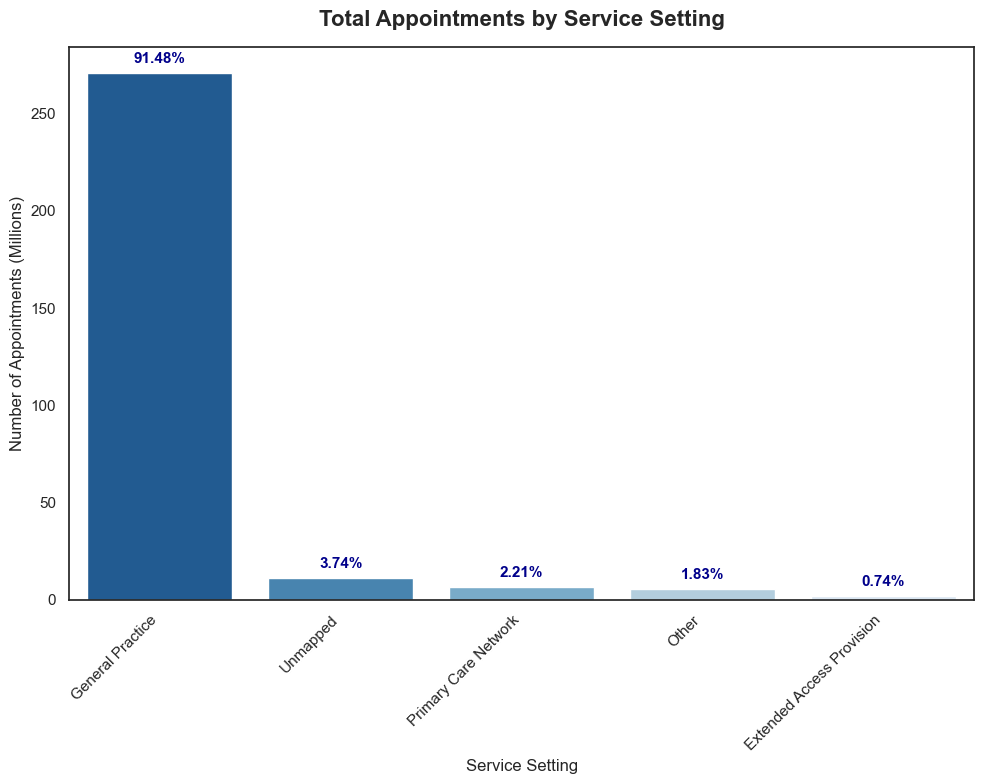

In [581]:
# Determine the number of service settings.
print(f"The number of service settings in the data set is: {nc['service_setting'].nunique()}")

# Apply count and plot function to show number of appointments & visualise the results.
print("""The amount of appointments for each service setting:""")
ss_results = count_and_plot(nc, 'service_setting', 'Total Appointments by Service Setting')

GPs make up the majority of appointments at over 91%.\
Primary Care Network only provides 2.2% of appointments - increasing PCN appointments would take some pressure off GPs.

### Context Type

The number of context types in the data set is: 3
The amount of appointments for each context type:
                        count_of_appointments  percentage
context_type                                             
Care Related Encounter              257075158       86.84
Inconsistent Mapping                 27890802        9.42
Unmapped                             11080810        3.74


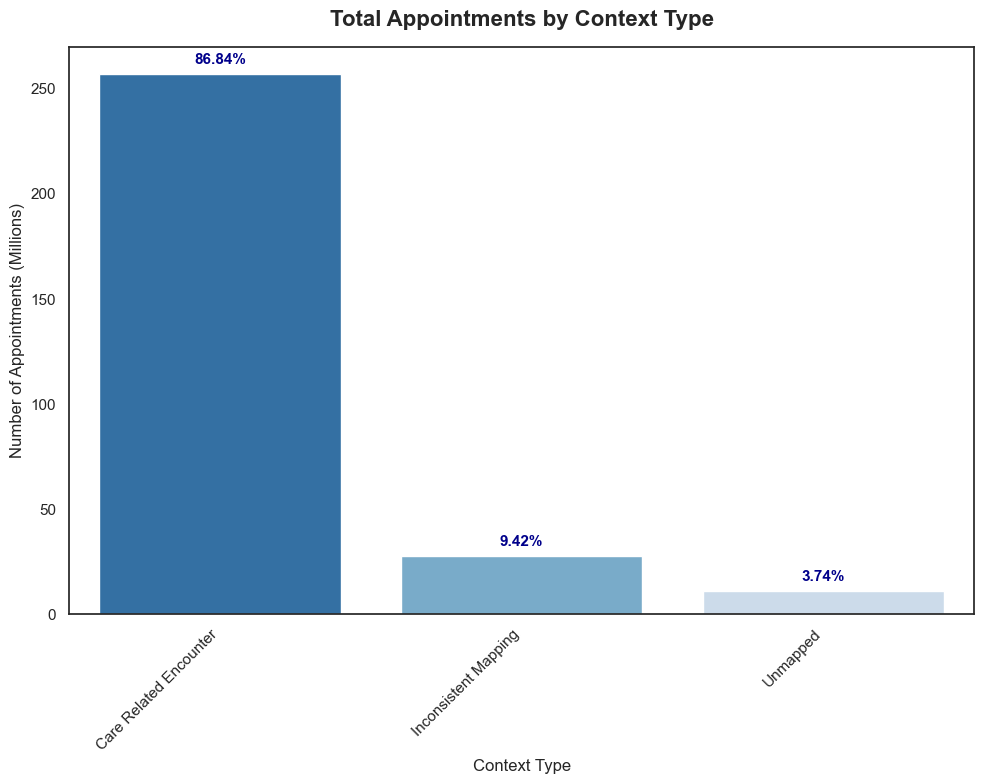

In [582]:
# Analyse total appointments by context type.
print(f"The number of context types in the data set is: {nc['context_type'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each context type:""")
context_results = count_and_plot(nc, 'context_type', 'Total Appointments by Context Type')

There are 3 context types in total (NHS): Care Related Encounter, Care Related Activities and Administration and practice staff activities.\
Although over 13% of appointments are marked as Inconsistent Mapping and Unmapped, as there are only 3 context types in total we can assume that this 13% is made up of Care Related Activities and Administration and practice staff activities.

### National categories

The number of national categories in the data set is: 18
The amount of appointments for each category:
                                                                     count_of_appointments  \
national_category                                                                            
General Consultation Routine                                                      97271522   
General Consultation Acute                                                        53691150   
Clinical Triage                                                                   41546964   
Planned Clinics                                                                   28019748   
Inconsistent Mapping                                                              27890802   
Planned Clinical Procedure                                                        25702694   
Unmapped                                                                          11080810   
Unplanned Clinical Activity                        

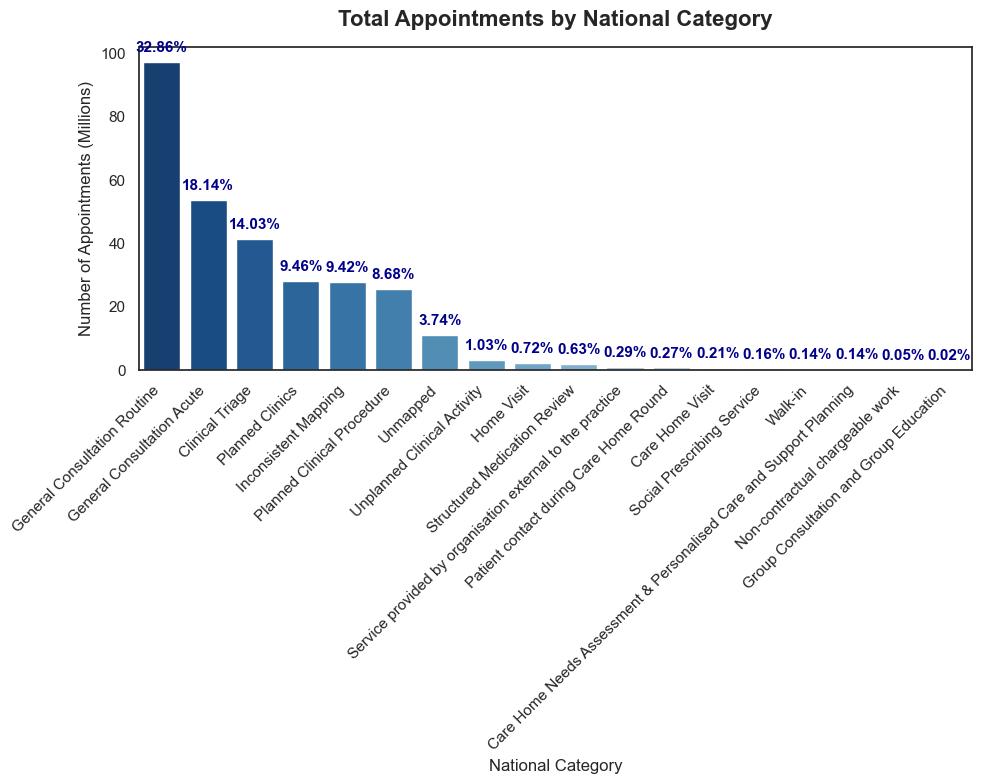

In [583]:
# Analyse appointments by national category.
print(f"The number of national categories in the data set is: {nc['national_category'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each category:""")
category_results = count_and_plot(nc, 'national_category', 'Total Appointments by National Category')

65% of all appointments are made up of General Consultation Routine, General Consultation Acute and Clinical Triage. \
13% is made up by Inconsistent Mapping and Unmapped - this needs to be reduced.\
Clinical triage can be face-to-face, online or by phone:\
<https://www.england.nhs.uk/long-read/digitally-enabled-triage/>

### Appointment status

The number of appointment statuses in the data set is: 3
The amount of appointments for each status:
                    count_of_appointments  percentage
appointment_status                                   
Attended                        677755876       91.24
Unknown                          34137416        4.60
DNA                              30911233        4.16


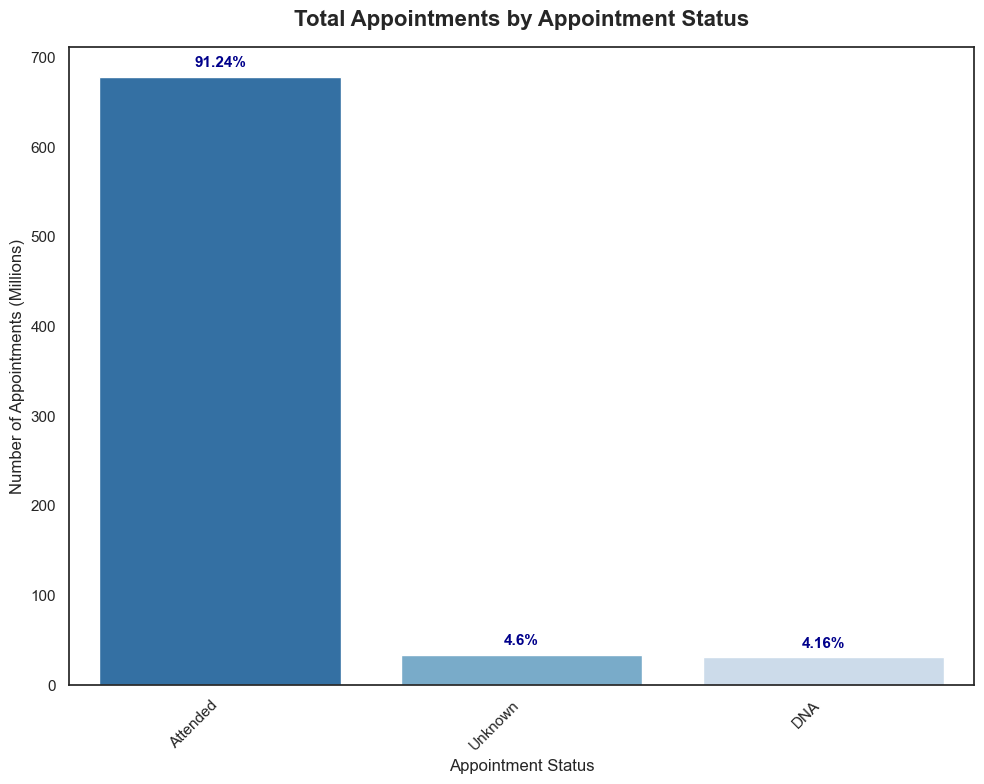

In [584]:
# Analyse the number of appointment by appointment status.
print(f"The number of appointment statuses in the data set is: {ar['appointment_status'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each status:""")
status_results = count_and_plot(ar, 'appointment_status', 'Total Appointments by Appointment Status')

4.16% of appointments are not attended - why? Is there a more common appointment type, service setting or context for not attended appointments?\
4.6% of appointments have an unknown status - this number needs to be decreased.

### HCP type

The number of health care practicioner types in the data set is: 3
The amount of appointments for each HCP type:
                      count_of_appointments  percentage
hcp_type                                               
GP                                379650140       51.11
Other Practice staff              339650535       45.73
Unknown                            23503850        3.16


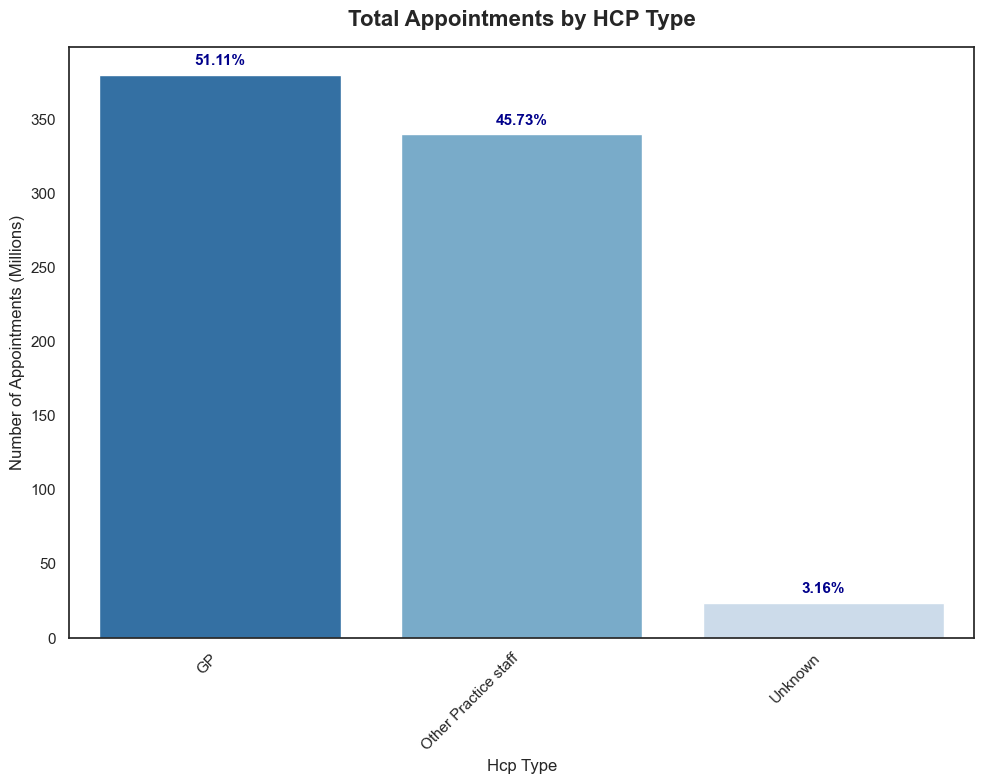

In [585]:
# Analyse the number of appointment by HCP type.
print(f"The number of health care practicioner types in the data set is: {ar['hcp_type'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each HCP type:""")
hcp_results = count_and_plot(ar, 'hcp_type', 'Total Appointments by HCP Type')

GPs make up over half of HCP types, 45% is made up by other practice staff - it would be helpful to have more granularity on this and be able to make a distinction between other types of staff.

### Appointment mode

The number of appointment modes in the data set is: 5
The amount of appointments for each appointment mode:
                  count_of_appointments  percentage
appointment_mode                                   
Face-to-Face                  439981729       59.23
Telephone                     267862657       36.06
Unknown                        26451305        3.56
Home Visit                      4887876        0.66
Video/Online                    3620958        0.49


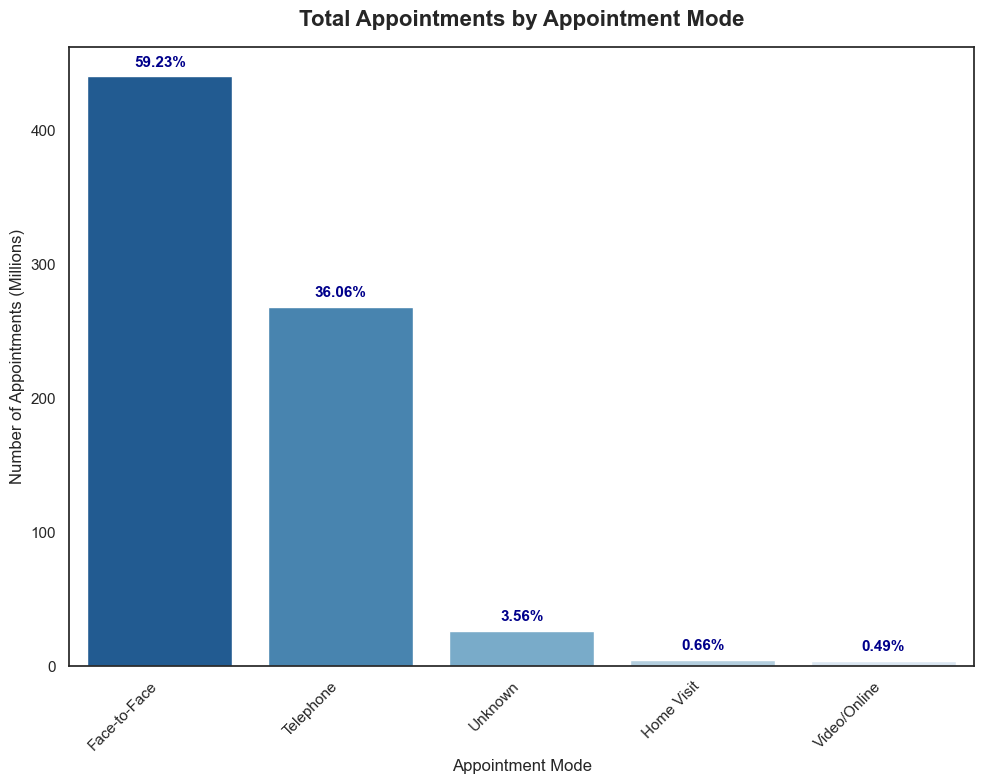

In [586]:
# Analyse the number of appointment by appointment mode.
print(f"The number of appointment modes in the data set is: {ar['appointment_mode'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each appointment mode:""")
mode_results = count_and_plot(ar, 'appointment_mode', 'Total Appointments by Appointment Mode')

Almost 60% of appointments are face-to-face, followed by telephone appointments at 36%.\
Video/online appointments make up only 0.49% - perhaps increasing this would decrease reliance on face-to-face appointments.

### Time between booking and appointment

The number of categories for time between booking and appointment is:8
The amount of appointments for each category:
                                   count_of_appointments  percentage
time_between_book_and_appointment                                   
Same Day                                       342747171       46.14
2 to 7 Days                                    153794531       20.70
8  to 14 Days                                   86846519       11.69
1 Day                                           67716097        9.12
15  to 21 Days                                  42710574        5.75
22  to 28 Days                                  25536541        3.44
More than 28 Days                               23050987        3.10
Unknown / Data Quality                            402105        0.05


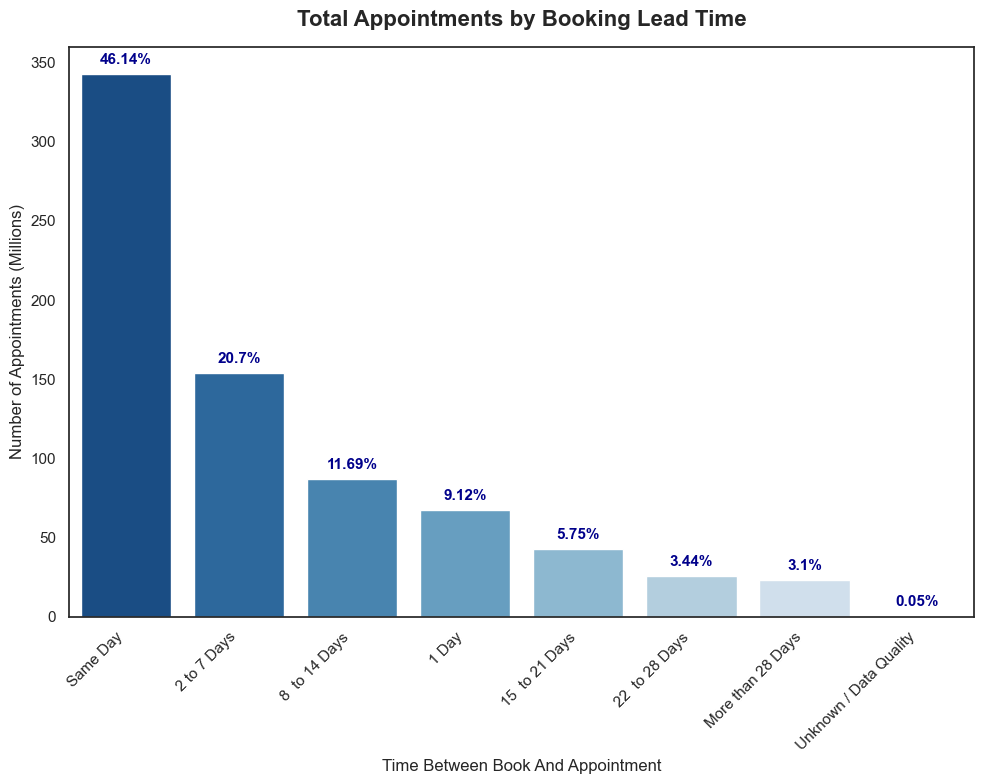

In [587]:
# Analyse the number of appointment by time between booking and appointment.
print(f"The number of categories for time between booking and appointment is:\
{ar['time_between_book_and_appointment'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each category:""")
time_results = count_and_plot(ar, 'time_between_book_and_appointment', 'Total Appointments by Booking Lead Time')

46% of appointments are same day appointments, followed by 20% of appointments booked 2-7 days in advance. \
Although this is good for patients, it shows most appointments are reactive/emergency care, leaving little capacity for planned care.

### Actual duration

The number of appointment durations in the data set is: 7
The amount of appointments for each appointment duration:
                        count_of_appointments  percentage
actual_duration                                          
Unknown / Data Quality               40284086       23.98
6-10 Minutes                         33800815       20.12
1-5 Minutes                          28600865       17.03
11-15 Minutes                        25160882       14.98
16-20 Minutes                        16004247        9.53
21-30 Minutes                        15026365        8.95
31-60 Minutes                         9103432        5.42


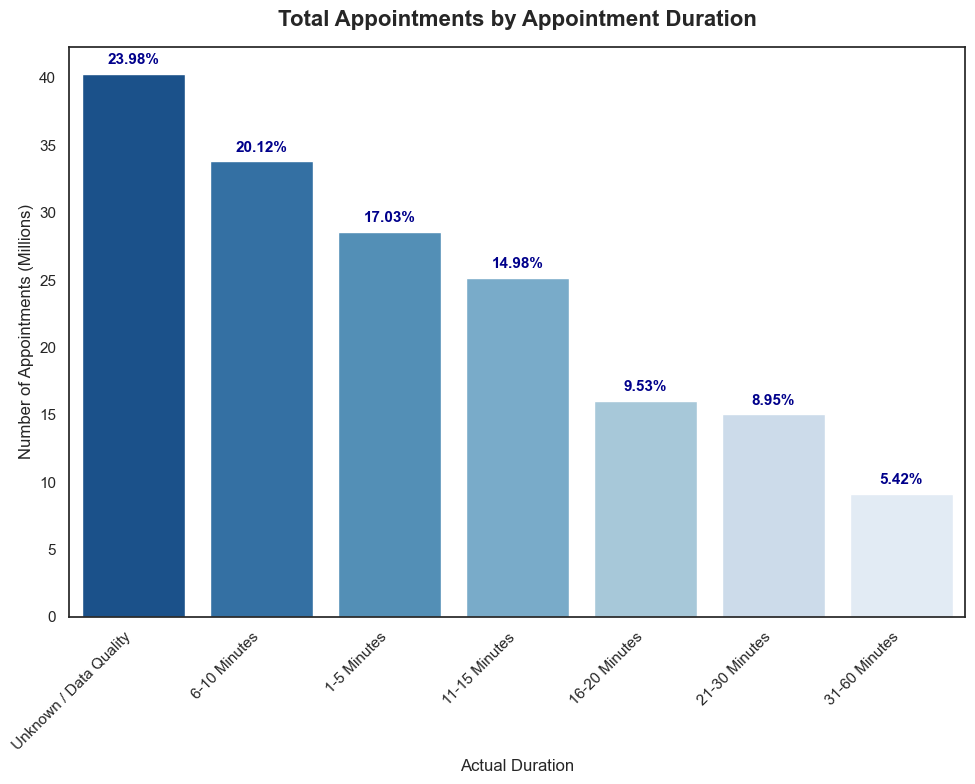

In [588]:
# Analyse the number of appointment by actual duration.
print(f"The number of appointment durations in the data set is: {ad['actual_duration'].nunique()}")

# Apply count and plot function.
print("""The amount of appointments for each appointment duration:""")
duration_results = count_and_plot(ad, 'actual_duration', 'Total Appointments by Appointment Duration')

Almost a quarter of appointments are of unknown duration, over 37% are between 1-10 minutes. \
Data quality issue needs to be addressed.\
Could number of short appointments be decreased?

# Assignment activity 3

### Continue to explore the data and search for answers to more specific questions posed by the NHS.

**Question 1:** Between what dates were appointments scheduled? 

In [26]:
# View the first five rows of appointment_date for the ad DataFrame to determine the date format.
ad['appointment_date'].head(5)

0    01-Dec-21
1    01-Dec-21
2    01-Dec-21
3    01-Dec-21
4    01-Dec-21
Name: appointment_date, dtype: object

In [27]:
# View the first five rows of appointment_date for the nc DataFrame to determine the date format.
nc['appointment_date'].head(5)

0   2021-08-02
1   2021-08-02
2   2021-08-02
3   2021-08-02
4   2021-08-02
Name: appointment_date, dtype: datetime64[ns]

In [29]:
# Change the date format of ad['appointment_date'].
ad['appointment_date'] = pd.to_datetime(ad['appointment_date'])

# View the DateFrame.
ad['appointment_date']

0        2021-12-01
1        2021-12-01
2        2021-12-01
3        2021-12-01
4        2021-12-01
            ...    
137788   2022-06-30
137789   2022-06-30
137790   2022-06-30
137791   2022-06-30
137792   2022-06-30
Name: appointment_date, Length: 137793, dtype: datetime64[ns]

In [30]:
# Change the date format of ar['appointment_date'].
ar['appointment_date'] = pd.to_datetime(ar['appointment_month'])

# View the DateFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2020-01-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2020-01-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2020-01-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2020-01-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2020-01-01
...,...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21,2022-06-01
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8,2022-06-01
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28,2022-06-01
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17,2022-06-01


In [32]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
min_max = ad['appointment_date'].agg(['min', 'max'])

print(f"The minimum appointment date is: {min_max['min'].strftime('%-d-%B-%Y')}")
print(f"The maximum appointment date is: {min_max['max'].strftime('%-d-%B-%Y')}")

The minimum appointment date is: 1-December-2021
The maximum appointment date is: 30-June-2022


In [33]:
# Determine the minimum and maximum dates in the nc DataFrame.
# Use appropriate docstrings.
nc_min_max = nc['appointment_date'].agg(['min', 'max'])

print(f"The minimum appointment date is: {nc_min_max['min'].strftime('%-d-%B-%Y')}")
print(f"The maximum appointment date is: {nc_min_max['max'].strftime('%-d-%B-%Y')}")

The minimum appointment date is: 1-August-2021
The maximum appointment date is: 30-June-2022


In [34]:
# Determine the minimum and maximum dates in the ad DataFrame.
# Use appropriate docstrings.
ar_min_max = ar['appointment_date'].agg(['min', 'max'])

print(f"The minimum appointment date is: {ar_min_max['min'].strftime('%-d-%B-%Y')}")
print(f"The maximum appointment date is: {ar_min_max['max'].strftime('%-d-%B-%Y')}")

The minimum appointment date is: 1-January-2020
The maximum appointment date is: 1-June-2022


The timeframe of data sets is different - this will affect analysis / comparison between data sets.

**Question 2:** Which service setting was the most popular for NHS North West London from 1 January to 1 June 2022?

In [441]:
# For each of these service settings, determine the number of records available for the period and the location. 
start_date = '2022-01-01'
end_date = '2022-06-01'
location = 'NHS North West London ICB - W2U3Z'

# Create a mask to filter the df.
mask = (nc['sub_icb_location_name'] == location) & \
       (nc['appointment_date'] >= start_date) & \
       (nc['appointment_date'] <= end_date)

filtered_nc = nc.loc[mask]

# Group by service and sum the appointment count.
service_totals = filtered_nc.groupby('service_setting')\
                ['count_of_appointments'].sum().sort_values(ascending=False)

# View the output.
print("Service Ranking for NHS North West London from 1 January to 1 June 2022:")
print(service_totals)


Service Ranking for NHS North West London from 1 January to 1 June 2022:
service_setting
General Practice             4804239
Unmapped                      391106
Other                         152897
Primary Care Network          109840
Extended Access Provision      98159
Name: count_of_appointments, dtype: int64


In [36]:
# Print the most popular service:
top_service = service_totals.idxmax()
print("""The most popular service is:""", top_service)

The most popular service is: General Practice


In [439]:
# Group by context type and sum the appointment count.
context_totals = filtered_nc.groupby('context_type')\
                ['count_of_appointments'].sum().sort_values(ascending=False)

# View the output.
print("Context Type Ranking for NHS North West London from 1 January to 1 June 2022:")
print(context_totals)

Context Type Ranking for NHS North West London from 1 January to 1 June 2022:
context_type
Care Related Encounter    4641781
Inconsistent Mapping       523354
Unmapped                   391106
Name: count_of_appointments, dtype: int64


In [38]:
# Group by context type and sum the appointment count.
context_totals = filtered_nc.groupby('context_type')['count_of_appointments'].sum().to_frame()
grand_total = context_totals['count_of_appointments'].sum()
context_totals['percentage'] = (context_totals['count_of_appointments'] / grand_total * 100)

# View the output.
print("Context Type Ranking for NHS North West London from 1 January to 1 June 2022:")
print(context_totals)

Context Type Ranking for NHS North West London from 1 January to 1 June 2022:
                        count_of_appointments  percentage
context_type                                             
Care Related Encounter                4641781   83.541751
Inconsistent Mapping                   523354    9.419210
Unmapped                               391106    7.039040


In [438]:
# Group by national category and sum the appointment count.
category_totals = filtered_nc.groupby('national_category')['count_of_appointments']\
                .sum().to_frame().sort_values(by='count_of_appointments',ascending=False)

# View the output.
print("National Category Ranking for NHS North West London from 1 January to 1 June 2022:")
print(category_totals)

National Category Ranking for NHS North West London from 1 January to 1 June 2022:
                                                                     count_of_appointments
national_category                                                                         
General Consultation Routine                                                       1509613
Planned Clinics                                                                    1064471
Clinical Triage                                                                     864031
General Consultation Acute                                                          747912
Inconsistent Mapping                                                                523354
Unmapped                                                                            391106
Planned Clinical Procedure                                                          282940
Unplanned Clinical Activity                                                          62760
Structu

In [40]:
# Calculate percentages of top 3 categories.
nc_counts = category_totals.groupby('national_category')['count_of_appointments'].sum()
general_count = nc_counts['General Consultation Routine']
planned_count = nc_counts['Planned Clinics']
triage_count = nc_counts['Clinical Triage']
total_nc_appointments = nc_counts.sum()

# Calculate the percentage.
general_percentage = (general_count / total_nc_appointments) * 100
planned_percentage = (planned_count / total_nc_appointments) * 100
triage_percentage = (triage_count / total_nc_appointments) * 100

print(f"Total Appointments: {total_appointments:,}")
print(f"Total General Consultation Appointments: {general_count:,}")
print(f"Percentage of General Consultation Appointments: {general_percentage:.2f}%")
print(f"Total Planned Clinics Appointments: {planned_count:,}")
print(f"Percentage of Planned Clinics Appointments: {planned_percentage:.2f}%")
print(f"Total Clinical Triage Appointments: {triage_count:,}")
print(f"Percentage of Clinical Triage Appointments: {triage_percentage:.2f}%")

Total Appointments: 742,804,525
Total General Consultation Appointments: 1,509,613
Percentage of General Consultation Appointments: 27.17%
Total Planned Clinics Appointments: 1,064,471
Percentage of Planned Clinics Appointments: 19.16%
Total Clinical Triage Appointments: 864,031
Percentage of Clinical Triage Appointments: 15.55%


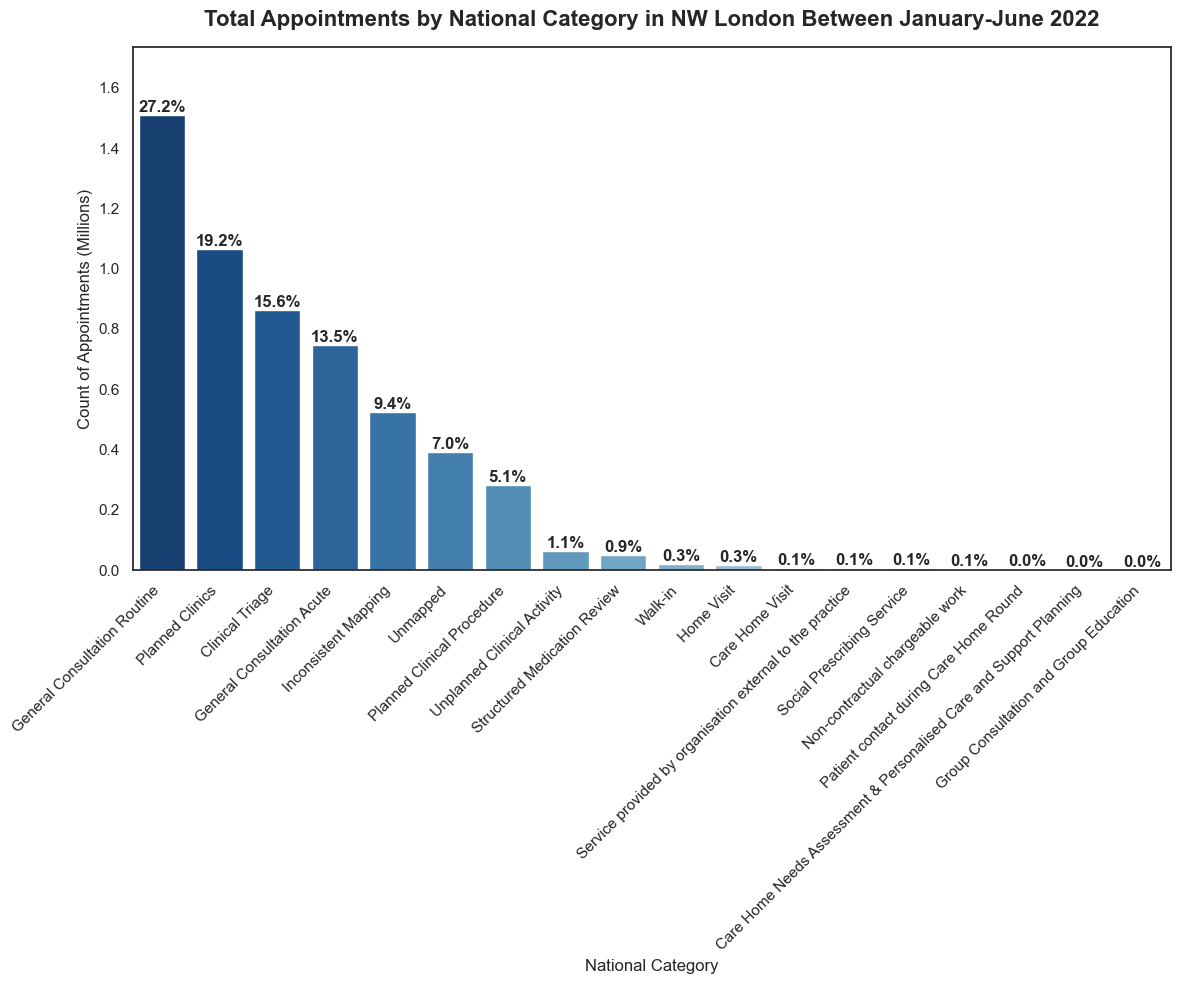

In [589]:
# Plot results.
total_appointments = category_totals['count_of_appointments'].sum() / 1_000_000

plt.figure(figsize=(12, 10))
ax = sns.barplot(
    x=category_totals.index, 
    y=category_totals['count_of_appointments'] / 1_000_000, 
    palette='Blues_r'
)

# Add percentages on top of bars.
for container in ax.containers:
    labels = [f'{(v.get_height() / total_appointments * 100):.1f}%' for v in container]
    ax.bar_label(container, labels=labels, fontsize=12, fontweight='bold')

# Format plot title and labels
plt.title('Total Appointments by National Category in NW London Between January-June 2022', 
          fontsize=16, 
          fontweight='bold', 
          pad=15)
plt.xlabel('National Category', fontsize=12)
plt.ylabel('Count of Appointments (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add extra headroom on the Y-axis so labels don't get cut off
plt.ylim(0, (category_totals['count_of_appointments'].max() / 1_000_000) * 1.15)

plt.tight_layout()
plt.savefig('total_appointments_by_nc_in_nw_london_between_jan_june_2022.png', dpi=300)
plt.show()

In NW London planned clinics replace general consultation acute as second most popular category, general consultation routine remains most popular with 27.2% of appointments in this category.

**Question 3:** Which month had the highest number of appointments?

In [42]:
# Number of appointments per month == sum of count_of_appointments by month.
# Use the groupby() and sort_values() functions.
monthly_app = ar.groupby([
    ar['appointment_date'].dt.year.rename('year'), 
    ar['appointment_date'].dt.month.rename('month')
])['count_of_appointments'].sum().reset_index()

monthly_app = monthly_app.set_index(['year', 'month']).sort_values('count_of_appointments', ascending=False)
monthly_app

count_of_appointments
year month                       
2021 11                  30405070
     10                  30303834
2022 3                   29595038
2021 9                   28522501
2020 10                  28301932
2022 5                   27495508
2021 3                   27225424
2020 1                   27199296
2021 6                   26784182
2020 9                   26714255
2022 6                   25828078
2021 7                   25739219
2022 1                   25635474
     2                   25355260
2021 12                  25140776
2020 11                  25061602
     2                   24104621
     3                   24053468
2022 4                   23913060
2021 4                   23879932
     8                   23852171
2020 12                  23535936
2021 5                   23508395
     1                   22492069
2020 7                   22491437
2021 2                   22399569
2020 6                   20690805
     8                   20150520
     5                   16417212
     4                   16007881

October and November of 2021 had the highest number of appointments, followed by March 2022. 

**Question 4:** What was the total number of records per month?

In [449]:
# Total number of records per month.
monthly_counts = ar.groupby([ar['appointment_date'].dt.year, 
                             ar['appointment_date'].dt.month]).size()
monthly_counts

appointment_date  appointment_date
2020              1                   20889
                  2                   20689
                  3                   21350
                  4                   19124
                  5                   18338
                  6                   18844
                  7                   19502
                  8                   19247
                  9                   20043
                  10                  20122
                  11                  19675
                  12                  19394
2021              1                   19319
                  2                   18949
                  3                   19369
                  4                   19452
                  5                   19384
                  6                   19814
                  7                   19899
                  8                   19786
                  9                   20441
                  10                  205

In [450]:
print(f"Minimum records: {monthly_counts.min()}")
print(f"Maximum records: {monthly_counts.max()}")

Minimum records: 18338
Maximum records: 21350


The difference between minimum and maximum records per month is 3,012 - depending on time of year?

# Assignment activity 4

### Create visualisations and identify possible monthly and seasonal trends in the data.

In [183]:
# Import the necessary libraries.
import seaborn as sns
import matplotlib.pyplot as plt

# Set figure size.
sns.set(rc={'figure.figsize':(14, 10)})

# Set the plot style as white.
sns.set_style('white')

In [45]:
### tasks: Create three visualisations indicating the number of appointments per month for service settings, 
#context types, and national categories.
# Create four visualisations indicating the number of appointments for service setting per season. 
#The seasons are summer (June to August 2021)autumn (September to November 2021), winter (December to February 2022), 
#and spring (March to May 2022).

### Objective 1
Create three visualisations indicating the number of appointments per month for service settings, context types, and national categories.

In [47]:
# Change the data type of the appointment month to string to allow for easier plotting.
nc['appointment_month'] = nc['appointment_date'].dt.strftime('%Y-%m')
print(nc.head())
print(nc.dtypes)

  appointment_date icb_ons_code                       sub_icb_location_name  \
0       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
1       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
2       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
3       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   
4       2021-08-02    E54000050  NHS North East and North Cumbria ICB - 00L   

        service_setting            context_type  \
0  Primary Care Network  Care Related Encounter   
1                 Other  Care Related Encounter   
2      General Practice  Care Related Encounter   
3      General Practice  Care Related Encounter   
4      General Practice  Care Related Encounter   

                        national_category  count_of_appointments  \
0  Patient contact during Care Home Round                      3   
1                         Planned Clinics                      7   
2             

In [48]:
ar['appointment_month'] = ar['appointment_date'].dt.strftime('%Y-%m')
print(ar.head())
print(ar.dtypes)

  icb_ons_code appointment_month appointment_status hcp_type appointment_mode  \
0    E54000034           2020-01           Attended       GP     Face-to-Face   
1    E54000034           2020-01           Attended       GP     Face-to-Face   
2    E54000034           2020-01           Attended       GP     Face-to-Face   
3    E54000034           2020-01           Attended       GP     Face-to-Face   
4    E54000034           2020-01           Attended       GP     Face-to-Face   

  time_between_book_and_appointment  count_of_appointments appointment_date  
0                             1 Day                   8107       2020-01-01  
1                    15  to 21 Days                   6791       2020-01-01  
2                       2 to 7 Days                  20686       2020-01-01  
3                    22  to 28 Days                   4268       2020-01-01  
4                     8  to 14 Days                  11971       2020-01-01  
icb_ons_code                                 

In [302]:
# Aggregate on monthly level and determine the sum of records per month.
monthly_app = ar.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# View output.
monthly_app

,appointment_month,count_of_appointments
0,2020-01,27199296
1,2020-02,24104621
2,2020-03,24053468
3,2020-04,16007881
4,2020-05,16417212
5,2020-06,20690805
6,2020-07,22491437
7,2020-08,20150520
8,2020-09,26714255
9,2020-10,28301932


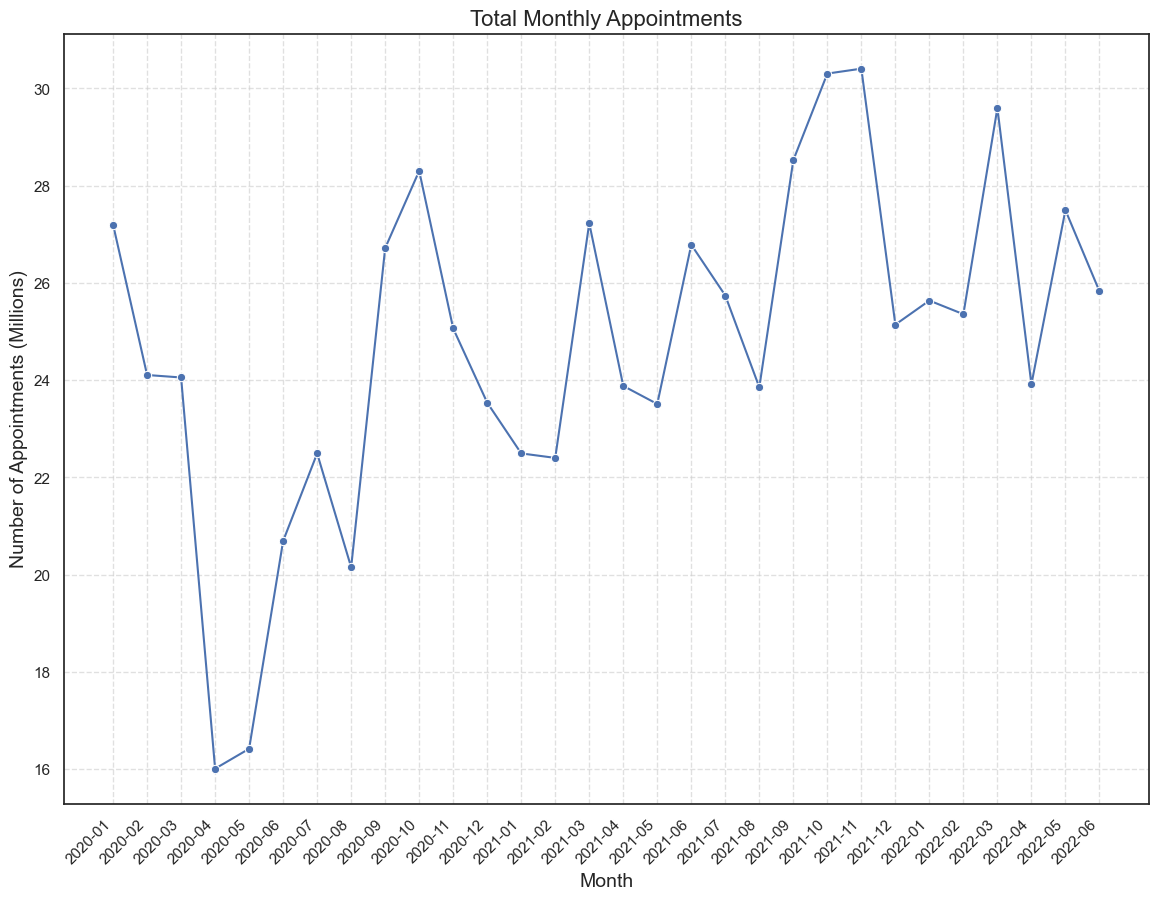

In [590]:
# Plot results.
sns.lineplot(x='appointment_month', 
             y=monthly_app['count_of_appointments'] / 1_000_000, 
             data=monthly_app, 
             errorbar=None, 
             marker='o')

# Format plot.
plt.title('Total Monthly Appointments', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Appointments (Millions)', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6, axis='both')
plt.savefig('total_monthly_appoitnments.png', dpi=300)

Sharp decline in appointment numbers end of March 2020, coinciding with the first UK lockdown.\
Appoitnment numbers increase again around May - after lockdown restrictions were eased.\
Sharp rise in September 2020 following additional ease of restrictions in August 2020.\
The highest number of appointments was in October and November 2021 (consistent with earlier findings), followed by a sharp decrease until February 2022 and sharp rise again in March 2022.

In [304]:
# Zoom on August 2021 - June 2022 using nc data set.
monthly_app_nc = nc.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# View output.
monthly_app_nc

,appointment_month,count_of_appointments
0,2021-08,23852171
1,2021-09,28522501
2,2021-10,30303834
3,2021-11,30405070
4,2021-12,25140776
5,2022-01,25635474
6,2022-02,25355260
7,2022-03,29595038
8,2022-04,23913060
9,2022-05,27495508


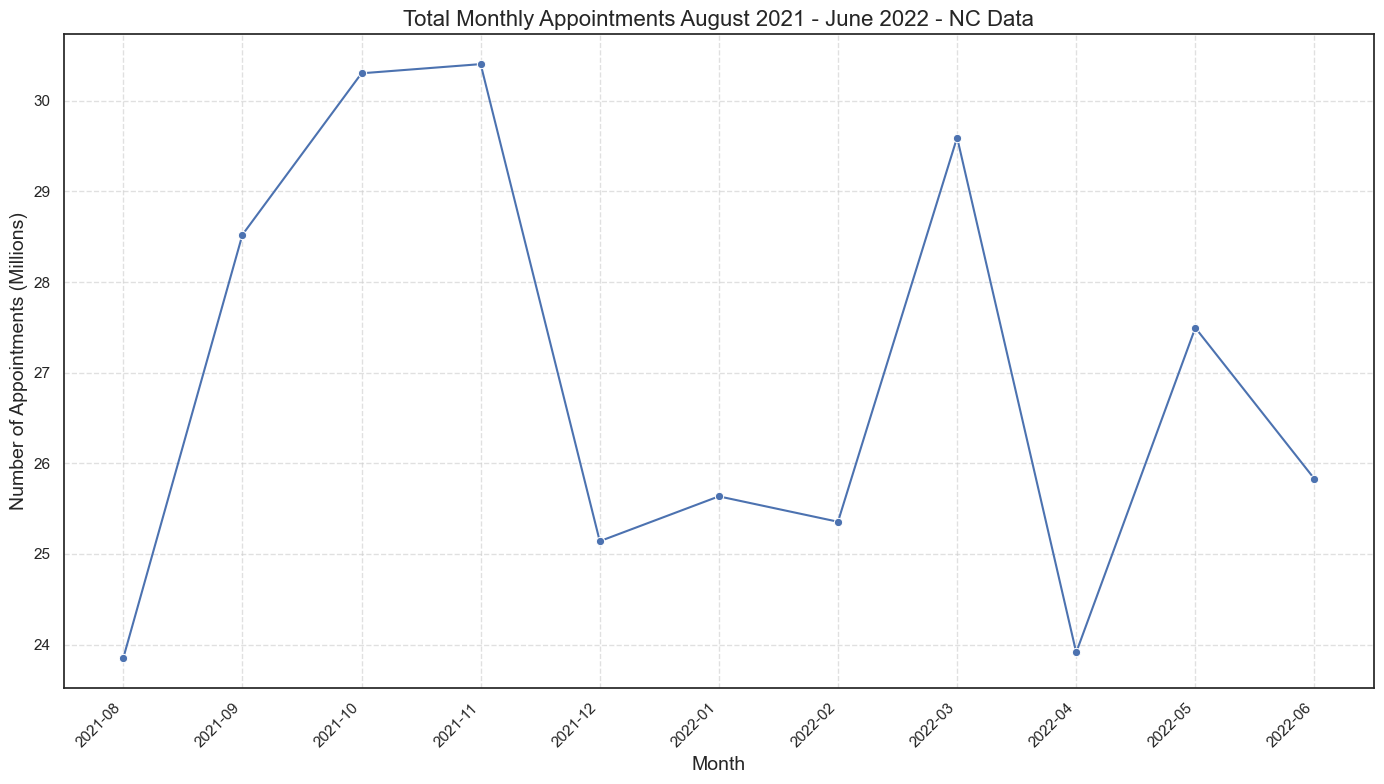

In [594]:
# Plot results.
plt.figure(figsize=(14, 8))
sns.lineplot(x='appointment_month', 
             y=monthly_app_nc['count_of_appointments'] / 1_000_000, 
             data=monthly_app_nc,
             marker='o',
             errorbar=None, 
             )

# Format plot.
plt.title('Total Monthly Appointments August 2021 - June 2022 - NC Data', fontsize=16)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of Appointments (Millions)', fontsize=14)
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45, ha='right');
plt.grid(True, linestyle='--', alpha=0.6, axis='both')
plt.tight_layout()
plt.savefig('total_monthly_appointments_august_2021_june_2022_nc_data.png', dpi=300)
plt.show()

**Service settings:**

In [437]:
# Create new df.
ss_app = nc[['service_setting', 'count_of_appointments', 'appointment_month']]
ss_app_cnt = ss_app.groupby(['service_setting', 
                             'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
ss_app_cnt

,service_setting,appointment_month,count_of_appointments
0,Extended Access Provision,2021-08,160927
1,Extended Access Provision,2021-09,187906
2,Extended Access Provision,2021-10,209539
3,Extended Access Provision,2021-11,207577
4,Extended Access Provision,2021-12,173504
5,Extended Access Provision,2022-01,186375
6,Extended Access Provision,2022-02,196627
7,Extended Access Provision,2022-03,231905
8,Extended Access Provision,2022-04,192284
9,Extended Access Provision,2022-05,220511


In [558]:
# Write function to plot monthly appointment trends.
def monthly_trends(df, hue_column, title, show_legend=True, auto_save=True):
    """
    Plots monthly appointment trends segmented by a chosen category.
    """
    plt.figure(figsize=(14, 8))
    
    # Create a line plot (dividing y by 1M for readability).
    ax = sns.lineplot(
        x='appointment_month', 
        y=df['count_of_appointments'] / 1_000_000, 
        hue=hue_column, 
        data=df, 
        errorbar=None,
        marker='o',
        palette='colorblind'
    )
    
    # Format plot.
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Month', fontsize=14)
    plt.ylabel('Number of Appointments (Millions)', fontsize=14)
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.6, linewidth=0.8, axis='both')
    plt.tight_layout()
    
    # Move the legend outside the plot.
    if show_legend:
        plt.legend(bbox_to_anchor=(1, 1), 
                   loc='upper left', 
                   title=hue_column.replace('_', ' ').title())
    else:
        leg = ax.legend_
        if leg is not None:
            leg.remove()

    # Write loop to automatically save charts.
    if auto_save:
        # Convert title to lowercase and replace spaces/punctuation with underscores.
        clean_filename = re.sub(r'[^\w\s-]', '', title).strip().lower()
        clean_filename = re.sub(r'[-\s]+', '_', clean_filename) + '.png'
        plt.savefig(clean_filename, dpi=300, bbox_inches='tight')
    
    plt.show()

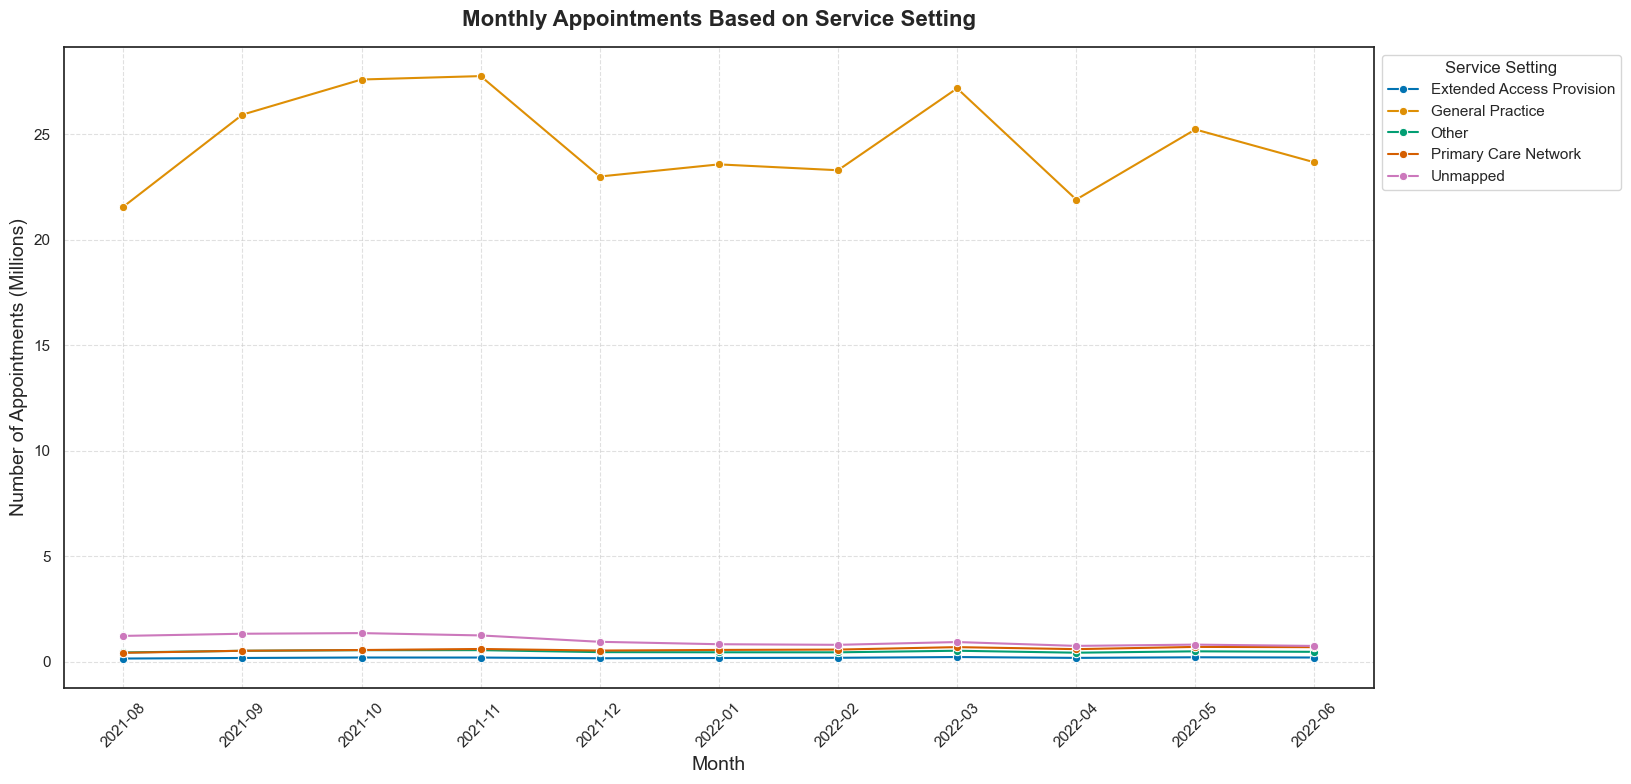

In [559]:
# Apply function to plot appointments based on service setting.
monthly_trends(ss_app_cnt, 
               'service_setting', 
               'Monthly Appointments Based on Service Setting')

In [463]:
# Plot appointments based on service setting filtering out General Practice.
# Create filter.
ss_filter = ss_app_cnt[ss_app_cnt['service_setting'] != 'General Practice']

# View df to sense check.
ss_filter

,service_setting,appointment_month,count_of_appointments
0,Extended Access Provision,2021-08,160927
1,Extended Access Provision,2021-09,187906
2,Extended Access Provision,2021-10,209539
3,Extended Access Provision,2021-11,207577
4,Extended Access Provision,2021-12,173504
5,Extended Access Provision,2022-01,186375
6,Extended Access Provision,2022-02,196627
7,Extended Access Provision,2022-03,231905
8,Extended Access Provision,2022-04,192284
9,Extended Access Provision,2022-05,220511


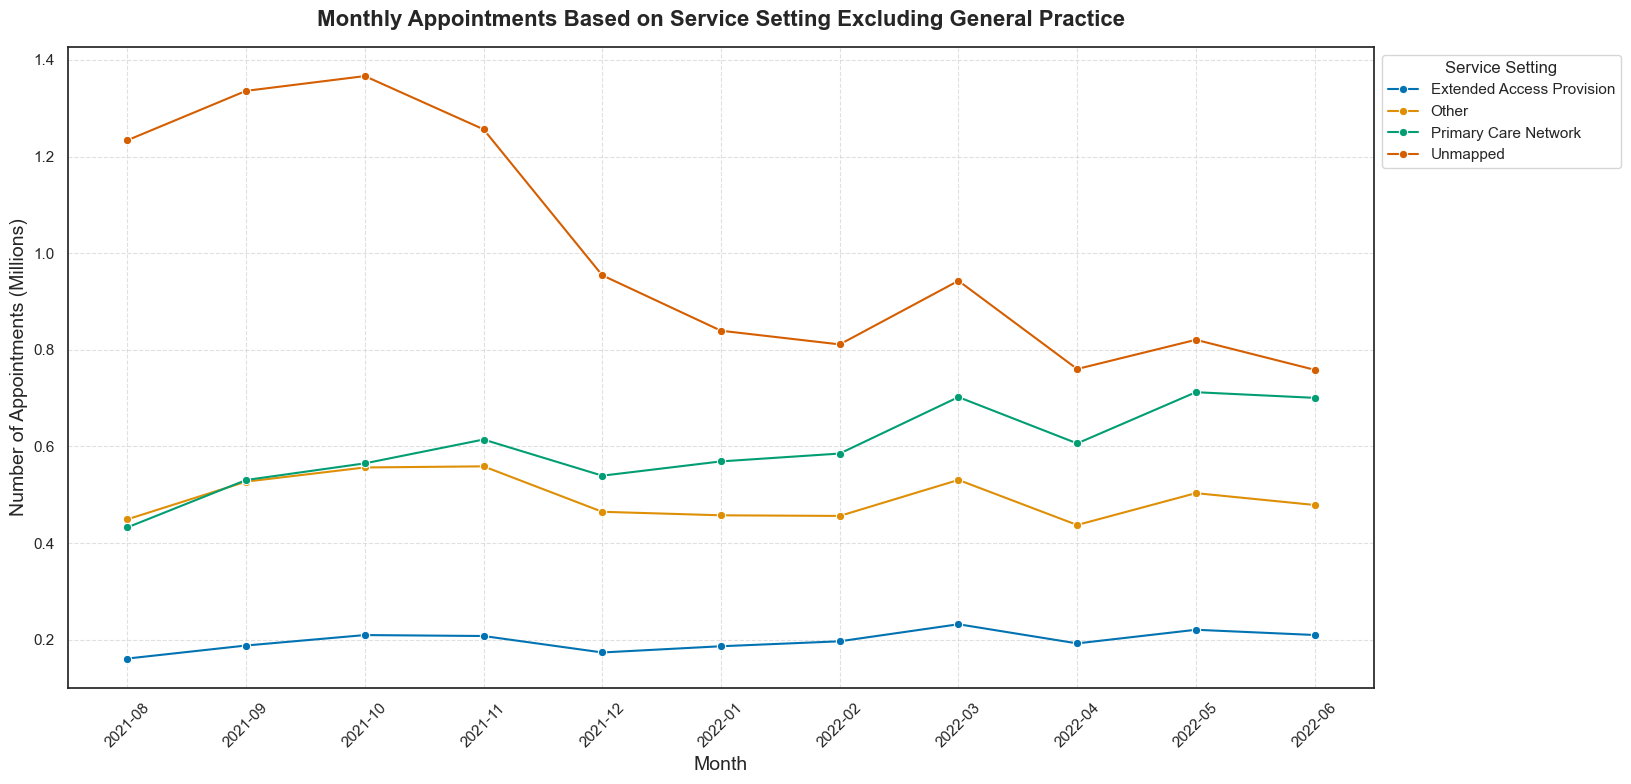

In [561]:
# Apply monthly trends function to visulatise results.
monthly_trends(ss_filter, 
               'service_setting', 
               'Monthly Appointments Based on Service Setting Excluding General Practice')

There is a marked decrease in unmapped appointments temporally, the amount of PCN appointments is on the rise.\
Extended access provision and other remain stable, all service settings experience sharp rise in February 2022, peaking in March 2022, following the overall trend of appointment numbers.

**Context types:**

In [434]:
# Create a separate data set that can be used in future weeks. 
ct_app = nc[['context_type', 'count_of_appointments', 'appointment_month']]
ct_app_cnt = ct_app.groupby(['context_type', 
                             'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
ct_app_cnt

,context_type,appointment_month,count_of_appointments
0,Care Related Encounter,2021-08,20255235
1,Care Related Encounter,2021-09,24404251
2,Care Related Encounter,2021-10,26125201
3,Care Related Encounter,2021-11,26282778
4,Care Related Encounter,2021-12,21798612
5,Care Related Encounter,2022-01,22441947
6,Care Related Encounter,2022-02,22211021
7,Care Related Encounter,2022-03,25928850
8,Care Related Encounter,2022-04,20904193
9,Care Related Encounter,2022-05,24101243


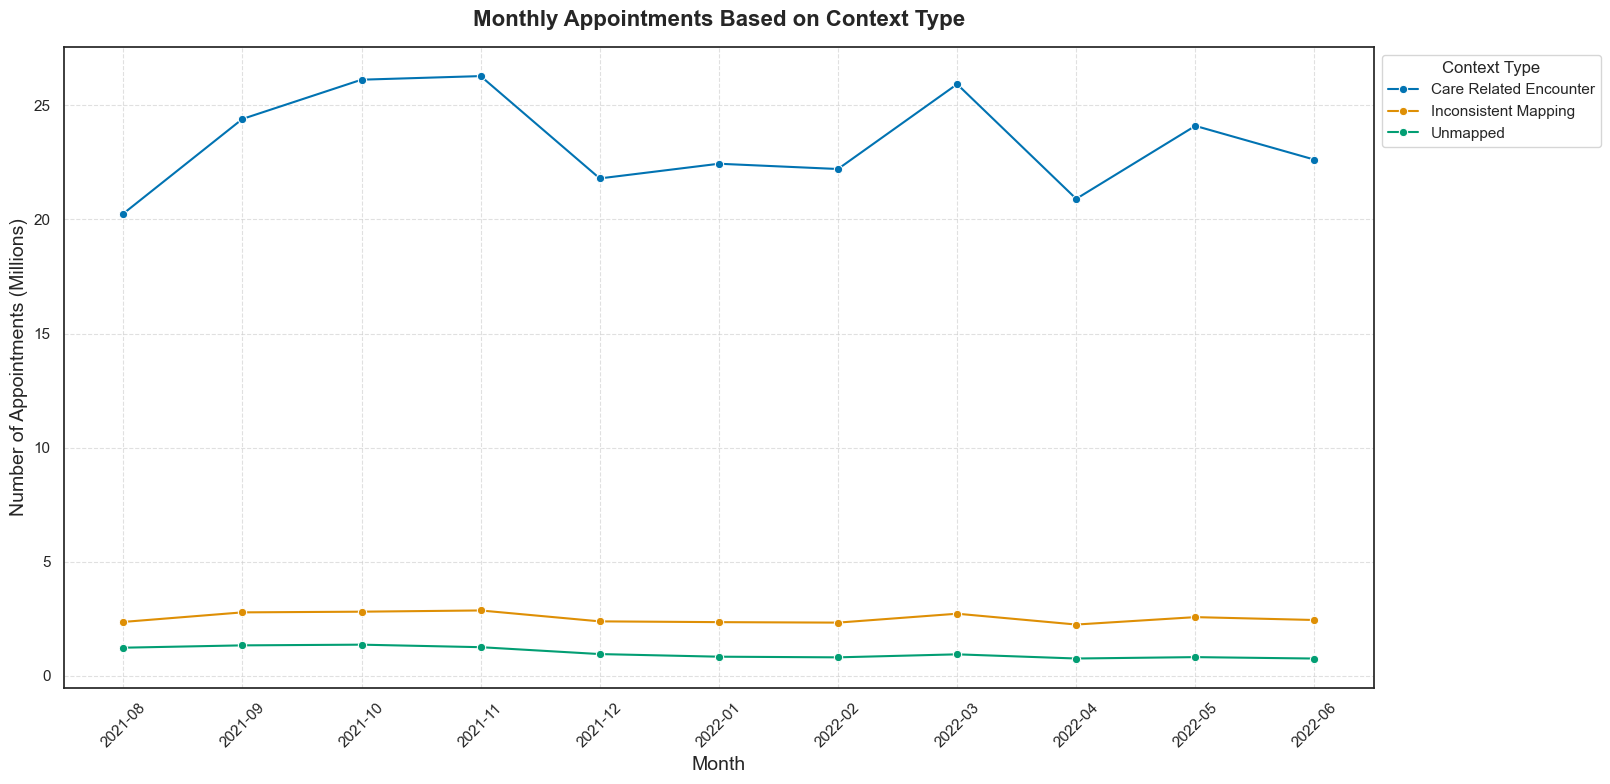

In [562]:
# Apply monthly trends function to visualise results.
monthly_trends(ct_app_cnt, 
               'context_type', 
               'Monthly Appointments Based on Context Type')

Care related encounters follow general trend of monthly appointments.

**National categories:**

In [58]:
# Create a separate data set that can be used in future weeks. 
nc_app = nc[['national_category', 'count_of_appointments', 'appointment_month']]
nc_app_cnt = nc_app.groupby(['national_category', 
                             'appointment_month'])['count_of_appointments'].sum().reset_index()

# View output.
nc_app_cnt

,national_category,appointment_month,count_of_appointments
0,Care Home Needs Assessment & Personalised Care...,2021-08,29676
1,Care Home Needs Assessment & Personalised Care...,2021-09,33503
2,Care Home Needs Assessment & Personalised Care...,2021-10,32441
3,Care Home Needs Assessment & Personalised Care...,2021-11,38827
4,Care Home Needs Assessment & Personalised Care...,2021-12,34653
...,...,...,...
193,Walk-in,2022-02,31665
194,Walk-in,2022-03,38070
195,Walk-in,2022-04,32346
196,Walk-in,2022-05,37687


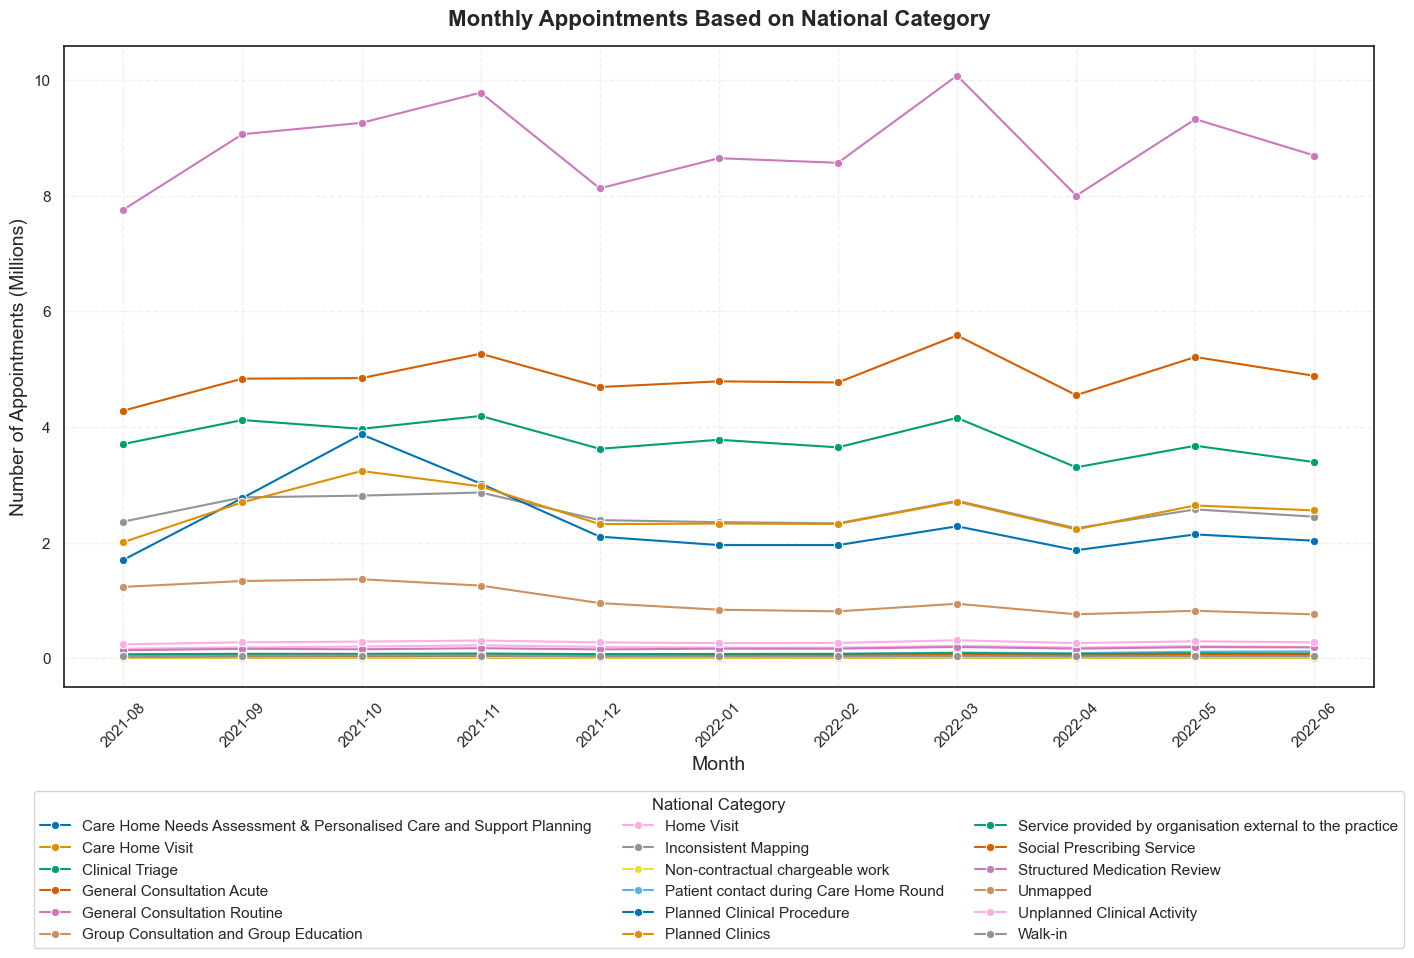

In [547]:
# Apply monthly trends fucntion to visualise national category data.
ax = monthly_trends(nc_app_cnt, 
                    'national_category', 
                    'Monthly Appointments Based on National Category', 
                    show_legend=False)

# Add legend manually underneath plot.
plt.legend(loc='upper center', title='National Category', bbox_to_anchor=(0.5, -0.15), ncol=3)
plt.savefig('monthly_appointments_based_on_national_category.png', dpi=300, bbox_inches='tight')
plt.show()

Most categories follow a similar trend over time, almost all display an increase in March 2022.\
Notably Planned Clinical Procedure stands out with a sharp increase from August-October 2021, when the top 3 categories displayed a decrease in appointment numbers.

### Objective 2
Create four visualisations indicating the number of appointments for service setting per season. The seasons are summer (June to August 2021), autumn (September to November 2021), winter (December to February 2022), and spring (March to May 2022).

**Summer (June to August 2021):**

In [61]:
# Create a separate data set that can be used in future weeks. 
nc_summer = nc[nc['appointment_date'].between('2021-08-01', '2021-08-30')]

# View output.
nc_summer.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [479]:
# Group by date and sum appointment counts.
nc_daily_august = nc_summer.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Sense check.
nc_daily_august.head()

,appointment_date,count_of_appointments
0,2021-08-01,5627
1,2021-08-02,1222768
2,2021-08-03,1169920
3,2021-08-04,1093532
4,2021-08-05,1074043


In [536]:
def daily_trends(df, title, auto_save=True):
    """
    Plots daily appointment trends with 1.2M capacity benchmark
    """
    plt.figure(figsize=(14, 8))
    
    # Plot daily appointment data (converted to millions)
    ax = sns.lineplot(
        x='appointment_date', 
        y=df['count_of_appointments'] / 1_000_000, 
        data=df,
        marker='o',
        linewidth=2,
        color='#1f77b4',
        errorbar=None,
        label='Daily Appointments'
    )
    
    # Add 1.2M capacity line
    ax.axhline(1.2, color='red', linestyle='--', linewidth=1.5, label='Capacity Limit (1.2M)')
    
    # Format plot.
    plt.title(title, fontsize=16, fontweight='bold', pad=15)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Number of Appointments (Millions)', fontsize=14)
    plt.xticks(rotation=45)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Set Y-axis limits to ensure benchmark is visible.
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()

    # Write loop to automatically save charts.
    if auto_save:
        # Convert title to lowercase and replace spaces/punctuation with underscores.
        clean_filename = re.sub(r'[^\w\s-]', '', title).strip().lower()
        clean_filename = re.sub(r'[-\s]+', '_', clean_filename) + '.png'
        plt.savefig(clean_filename, dpi=300, bbox_inches='tight')
        
    plt.show()

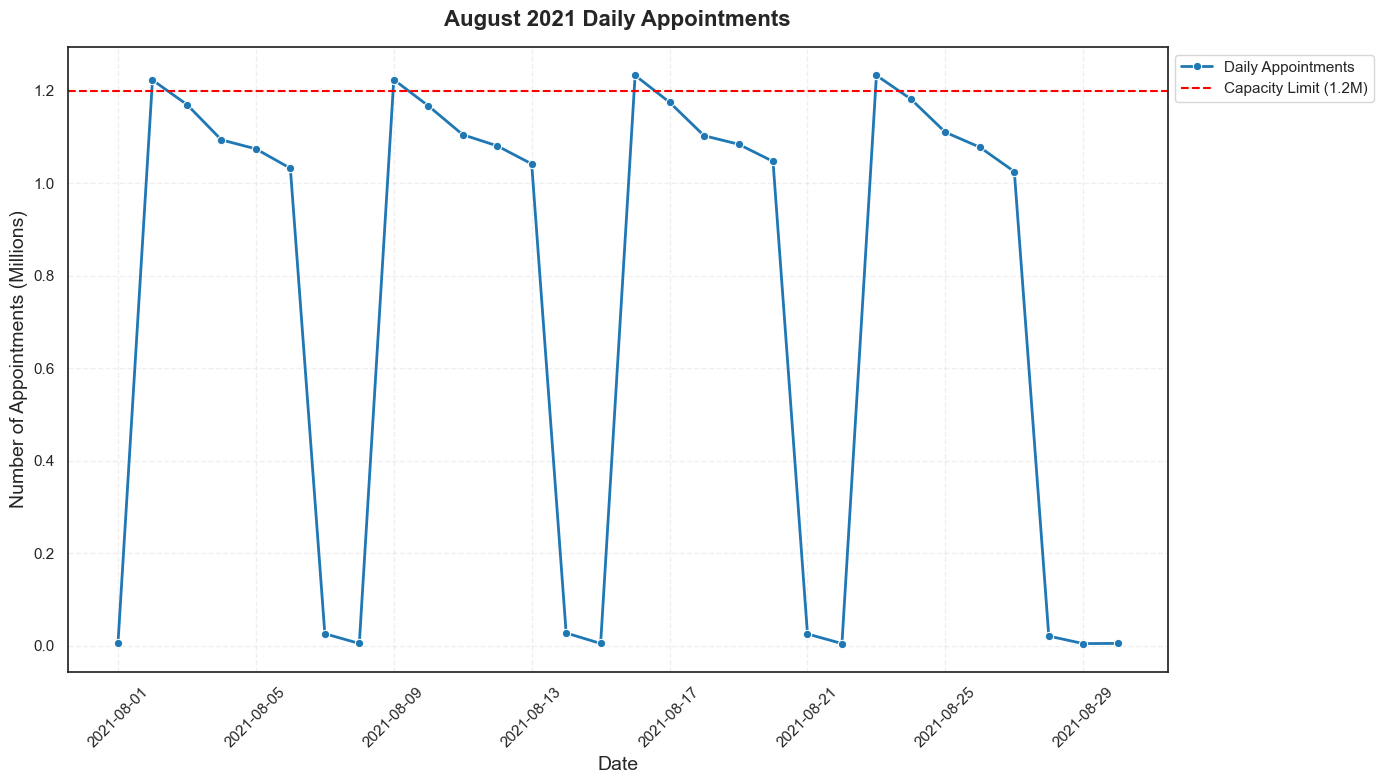

In [532]:
# Use daily trends function to display August 2021 appointments.
daily_trends(nc_daily_august, 'August 2021 Daily Appointments')

Only 1 month of data available for summer 2021, this doesn't give a full picture of appointment variability over the summer months.\
Difficult to compare with other seasons.\
Overall trend: sharp increase of appointments on a weekly basis every Monday, decrease over the week and sharp fall over the weekend.\
Every Monday capacity is exceeded, Tuesdays are almost at capacity.

**Autumn (September to November 2021):**

In [483]:
# Create a separate data set that can be used in future weeks. 
nc_autumn = nc[nc['appointment_date'].between('2021-09-01', '2021-11-30')]
nc_daily_autumn = nc_autumn.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Sense check.
nc_daily_autumn.head()

,appointment_date,count_of_appointments
0,2021-09-01,1149385
1,2021-09-02,1120509
2,2021-09-03,1086520
3,2021-09-04,26022
4,2021-09-05,5218


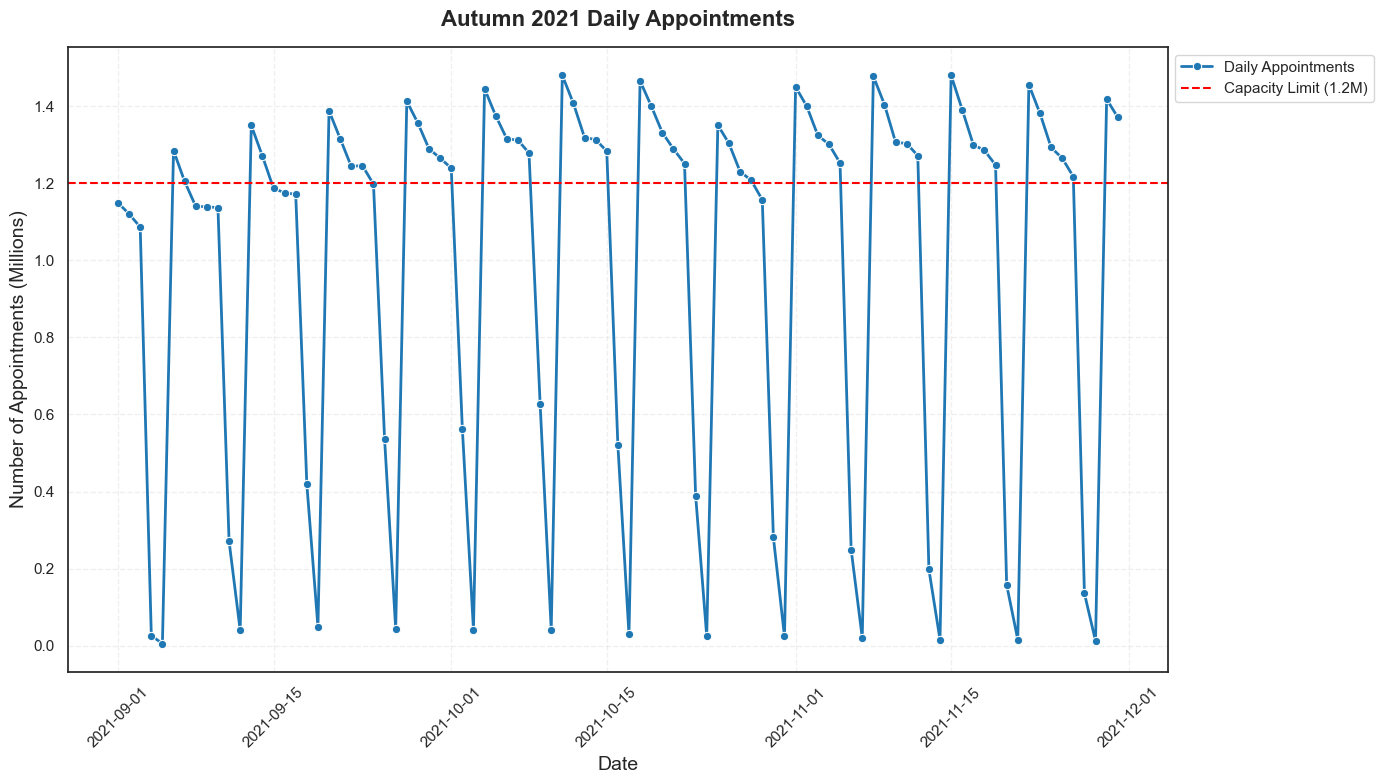

In [533]:
# Look at September to November 2021 in more detail to allow a closer look.
# Create a lineplot using the daily trends function.
daily_trends(nc_daily_autumn, 'Autumn 2021 Daily Appointments')

Majority of weeks in Autumn 2021 are over capacity Monday-Friday, with the exception of the first 3 weeks.\
Same weekly trend seen as in August - sharp fall in appointments every Saturday, and almost no appointments on Sundays.

**Winter (December to February 2022):**

In [511]:
# Create a separate data set that can be used in future weeks. 
nc_winter = nc[nc['appointment_date'].between('2021-12-01', '2022-02-28')]
nc_daily_winter = nc_winter.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# Sense check.
nc_daily_winter.head()

,appointment_date,count_of_appointments
0,2021-12-01,1270051
1,2021-12-02,1256511
2,2021-12-03,1210721
3,2021-12-04,101583
4,2021-12-05,12962


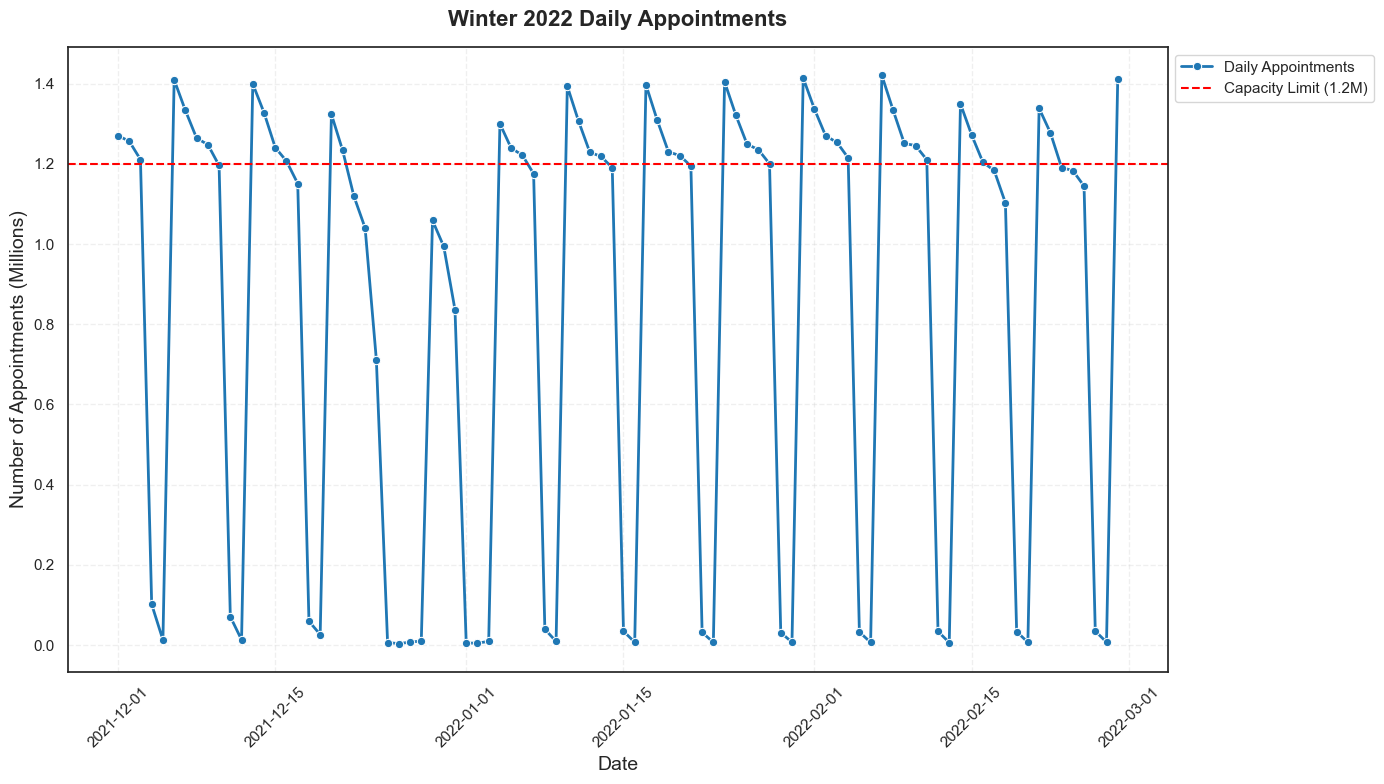

<Figure size 1400x1000 with 0 Axes>

In [534]:
# Look at December to February 2022 in more detail to allow a closer look.
# Create a lineplot using daily trends function.
daily_trends(nc_daily_winter, 'Winter 2022 Daily Appointments')
plt.savefig('Winter 2022 Daily Appointments')

Again, majority of weeks are above capacity, with the exception of the last week of December - likely due to Christmas holidays/celebrations.\
Difference between Saturday appointments in autumn and winter is of note - much lower in winter.

**Spring (March to May 2022):**

In [513]:
# Create a separate data set that can be used in future weeks. 
nc_spring = nc[nc['appointment_date'].between('2022-03-01', '2022-05-31')]
nc_daily_spring = nc_spring.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# View output.
nc_daily_spring.head()

,appointment_date,count_of_appointments
0,2022-03-01,1337865
1,2022-03-02,1267030
2,2022-03-03,1248737
3,2022-03-04,1215660
4,2022-03-05,36363


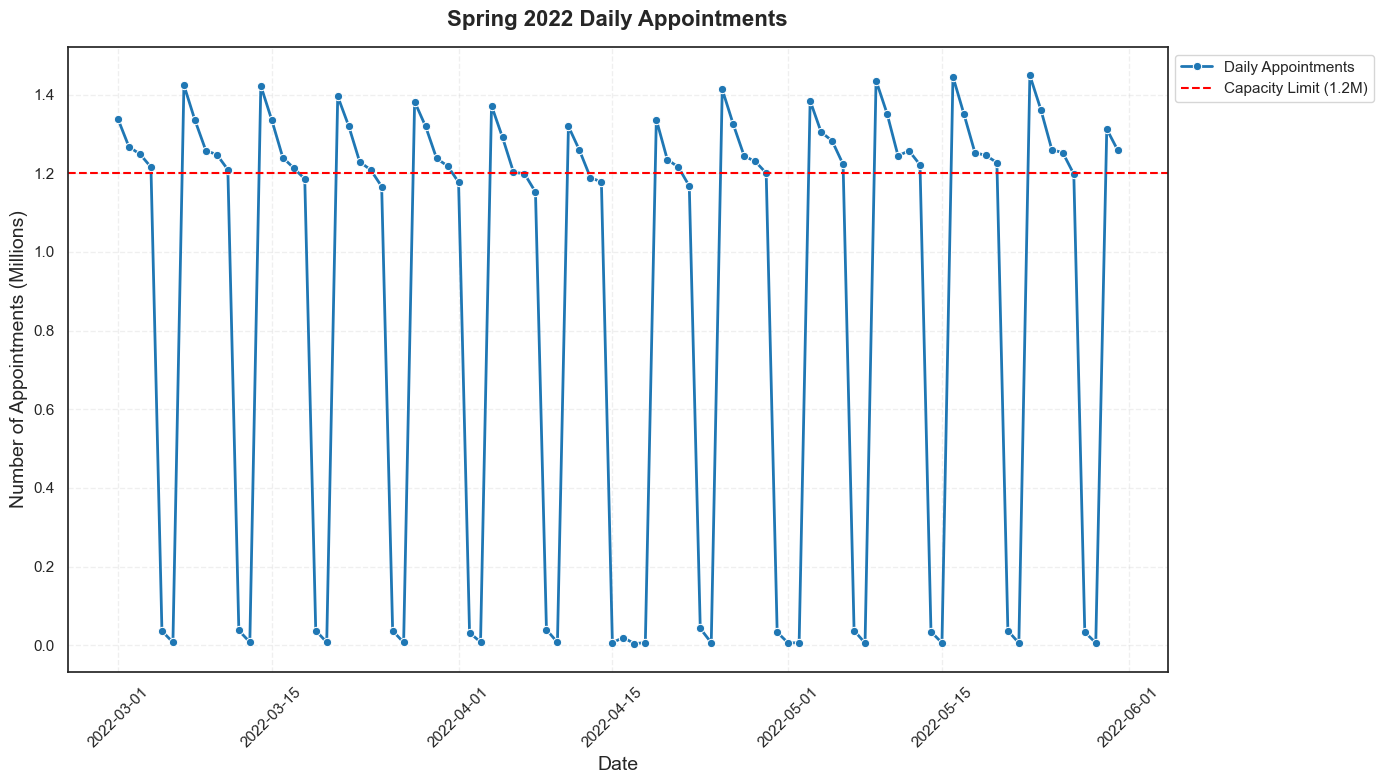

In [535]:
# Look at March to May 2022 in more detail to allow a closer look.
# Create a lineplot using daily trends function.
daily_trends(nc_daily_spring, 'Spring 2022 Daily Appointments')

Similar trend as previous seasons - most weeks over capacity, mid-April gap of 4 days with almost no appointments due to Easter holidays.\
Same weekly trend of almost no appointments on weekends, and highest number of appointments on Mondays.

# Assignment activity 5

### Analyse tweets from Twitter with hashtags related to healthcare in the UK.

In [69]:
# Libraries and settings needed for analysis
import pandas as pd
import seaborn as sns

# Set figure size.
sns.set(rc={'figure.figsize':(15, 12)})

# Set the plot style as white.
sns.set_style('white')

# Maximum column width to display
pd.options.display.max_colwidth = 200

In [70]:
# Load the data set.
tweets = pd.read_csv('tweets.csv')

# View the DataFrame.
tweets.head(5)

,tweet_id,tweet_full_text,tweet_entities,tweet_entities_hashtags,tweet_metadata,tweet_retweet_count,tweet_favorite_count,tweet_favorited,tweet_retweeted,tweet_lang
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be...","{'hashtags': [{'text': 'Healthcare', 'indices': [253, 264]}], 'symbols': [], 'user_mentions': [], 'urls': [{'url': 'https://t.co/yw0cstfmSI', 'expanded_url': 'https://bit.ly/3BiSKbs', 'display_url...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…,"{'hashtags': [{'text': 'PremiseHealth', 'indices': [94, 108]}, {'text': 'hiring', 'indices': [127, 134]}], 'symbols': [], 'user_mentions': [{'screen_name': 'AndreaGrammer', 'name': 'Andrea Grammer...","#PremiseHealth, #hiring","{'iso_language_code': 'en', 'result_type': 'recent'}",2,0,False,False,en
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…,"{'hashtags': [{'text': 'Healthcare', 'indices': [70, 81]}], 'symbols': [], 'user_mentions': [{'screen_name': 'OntarioGreens', 'name': 'Green Party of Ontario', 'id': 37115912, 'id_str': '37115912'...",#Healthcare,"{'iso_language_code': 'en', 'result_type': 'recent'}",39,0,False,False,en
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…,"{'hashtags': [{'text': 'NEW', 'indices': [20, 24]}], 'symbols': [], 'user_mentions': [{'screen_name': 'modrnhealthcr', 'name': 'Modern Healthcare', 'id': 18935711, 'id_str': '18935711', 'indices':...",#NEW,"{'iso_language_code': 'en', 'result_type': 'recent'}",5,0,False,False,en
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di...","{'hashtags': [{'text': 'blogs', 'indices': [184, 190]}, {'text': 'digitaltransformation', 'indices': [191, 213]}, {'text': 'cybersecurity', 'indices': [214, 228]}, {'text': 'accounting', 'indices'...","#blogs, #digitaltransformation, #cybersecurity, #accounting, #finance, #healthcare","{'iso_language_code': 'en', 'result_type': 'recent'}",0,0,False,False,en


In [515]:
# Explore the metadata.
tweets.dtypes

tweet_id                    int64
tweet_full_text            object
tweet_entities             object
tweet_entities_hashtags    object
tweet_metadata             object
tweet_retweet_count         int64
tweet_favorite_count        int64
tweet_favorited              bool
tweet_retweeted              bool
tweet_lang                 object
dtype: object

In [72]:
# Explore the data set.
print(tweets.describe())
print(tweets.info())

           tweet_id  tweet_retweet_count  tweet_favorite_count
count  1.174000e+03          1174.000000            1174.00000
mean   1.567612e+18             8.629472               0.37138
std    2.427553e+13            29.784675               2.04470
min    1.567574e+18             0.000000               0.00000
25%    1.567590e+18             0.000000               0.00000
50%    1.567611e+18             1.000000               0.00000
75%    1.567633e+18             3.000000               0.00000
max    1.567655e+18           303.000000              42.00000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1174 entries, 0 to 1173
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   tweet_id                 1174 non-null   int64 
 1   tweet_full_text          1174 non-null   object
 2   tweet_entities           1174 non-null   object
 3   tweet_entities_hashtags  1007 non-null   object
 4   twe

In [517]:
# Would it be useful to only look at retweeted and favourite tweet messages?
# Explain your answer.
tweets['tweet_retweet_count'].value_counts()

tweet_retweet_count
0      526
1      215
2      114
3       70
5       35
4       27
7       18
12      16
8       15
73      14
9       13
6       12
208     12
35      10
37       6
11       6
10       5
53       5
44       4
150      4
63       4
76       3
85       3
41       3
62       3
207      3
68       3
78       2
23       2
24       2
72       2
16       2
13       1
49       1
48       1
15       1
107      1
14       1
79       1
20       1
39       1
19       1
303      1
57       1
40       1
54       1
169      1
Name: count, dtype: int64

In [74]:
tweets['tweet_favorite_count'].value_counts()

tweet_favorite_count
0     1027
1       91
2       16
3       13
4        7
5        5
6        2
17       1
12       1
10       1
8        1
13       1
11       1
7        1
20       1
28       1
14       1
18       1
9        1
42       1
Name: count, dtype: int64

Almost half of tweets are not re-tweeted and almost all the tweets have not been favourited; it would not be useful to look at just these 2 metrics as they exclude too much information from the data set.

In [75]:
# Create a new DataFrame containing only the text.
tweets_text = tweets[['tweet_id', 'tweet_full_text']]

# View the DataFrame.
tweets_text

,tweet_id,tweet_full_text
0,1567629223795527681,"As Arkansas’ first Comprehensive Stroke Certified Center, UAMS provides Arkansans with access to the most advanced stoke care. Join us in our mission to make a difference in the health and well-be..."
1,1567582846612553728,RT @AndreaGrammer: Work-life balance is at the foundation of how decisions are made and where #PremiseHealth is headed. We're #hiring for…
2,1567582787070304256,RT @OntarioGreens: $10 billion can go a long way to fixing our broken #Healthcare system.\n\nYet Doug Ford would rather spend it ALL on a hig…
3,1567582767625428992,RT @modrnhealthcr: 🚨#NEW:🚨 Insurance companies are figuring out the best ways to collect information about members’ race and ethnicity data…
4,1567582720460570625,"ICYMI: Our recent blogs on Cybersecurity in Accounting https://t.co/4nnK0FiVVL and Digital Transformation in Healthcare Finance https://t.co/jIqn52lHD3 are a great read, take a look!\n\n#blogs #di..."
...,...,...
1169,1567583004209332227,RT @PotomacPhotonic: Potomac #Innovation Report: #precisionFabrication techniques Optimize #Microfluidic Mixing of Viscous Fluids \n\n#manuf…
1170,1567582945342267393,"Not a cent towards workers who would like to advance their training, especially those already employed by SHA or who for various reasons cannot obtain a student loan. Half of our department applie..."
1171,1567582936014241792,"The @hfmaorg Region 9 presents ""The Value of ESG to the Healthcare Industry"" and our own Kris Russell and Ron Present will be the key speakers. This #webinar will be taking place 9/13 and will exp..."
1172,1567582892892782592,Happy physiotherapy 🩺 day 🎉..\n#bpt #physiotherapy \n#HealthyNation #healthcare \n#medicalcare \n#csjmu .\n@WHO \n@MoHFW_INDIA \n@nitish_0210 https://t.co/NQHdIoYymC


In [76]:
# Loop through the messages, and create a list of values containing the # symbol.
tags = []

for y in [x.split(' ') for x in tweets['tweet_full_text'].values]:
    for z in y:
        if '#' in z:
            # Change to lowercase.
            tags.append(z.lower())

In [77]:
tags = pd.Series(tags)
tags_cnt = tags.value_counts()

In [78]:
# Display the first 30 records.
tags_cnt[:30]

#healthcare                    716
#health                         80
#medicine                       41
#ai                             40
#job                            38
#medical                        35
#strategy                       30
#pharmaceutical                 28
#digitalhealth                  25
#pharma                         25
#marketing                      25
#medtwitter                     24
#biotech                        24
#competitiveintelligence        24
#meded                          23
#vaccine                        18
#hiring                         18
#news                           17
#machinelearning                17
#technology                     17
#coronavirus                    16
#womeninmedicine                16
#covid                          16
#competitivemarketing           16
#wellness                       15
#healthtech                     15
#doctorofveterinarymedicine     14
#science                        14
#medicare           

In [79]:
# Convert the series to a DataFrame in preparation for visualisation.
tags = pd.DataFrame(tags_cnt).reset_index()

# Rename the columns.
tags.columns = ['Tags', 'Count']
tags

,Tags,Count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
...,...,...
1749,#evestudy,1
1750,#patientdata…,1
1751,#secure,1
1752,#sms,1


In [80]:
# Display records where the count is larger than 10.
tags_min_10 = tags[tags['Count']>10]
tags_min_10

,Tags,Count
0,#healthcare,716
1,#health,80
2,#medicine,41
3,#ai,40
4,#job,38
5,#medical,35
6,#strategy,30
7,#pharmaceutical,28
8,#digitalhealth,25
9,#pharma,25


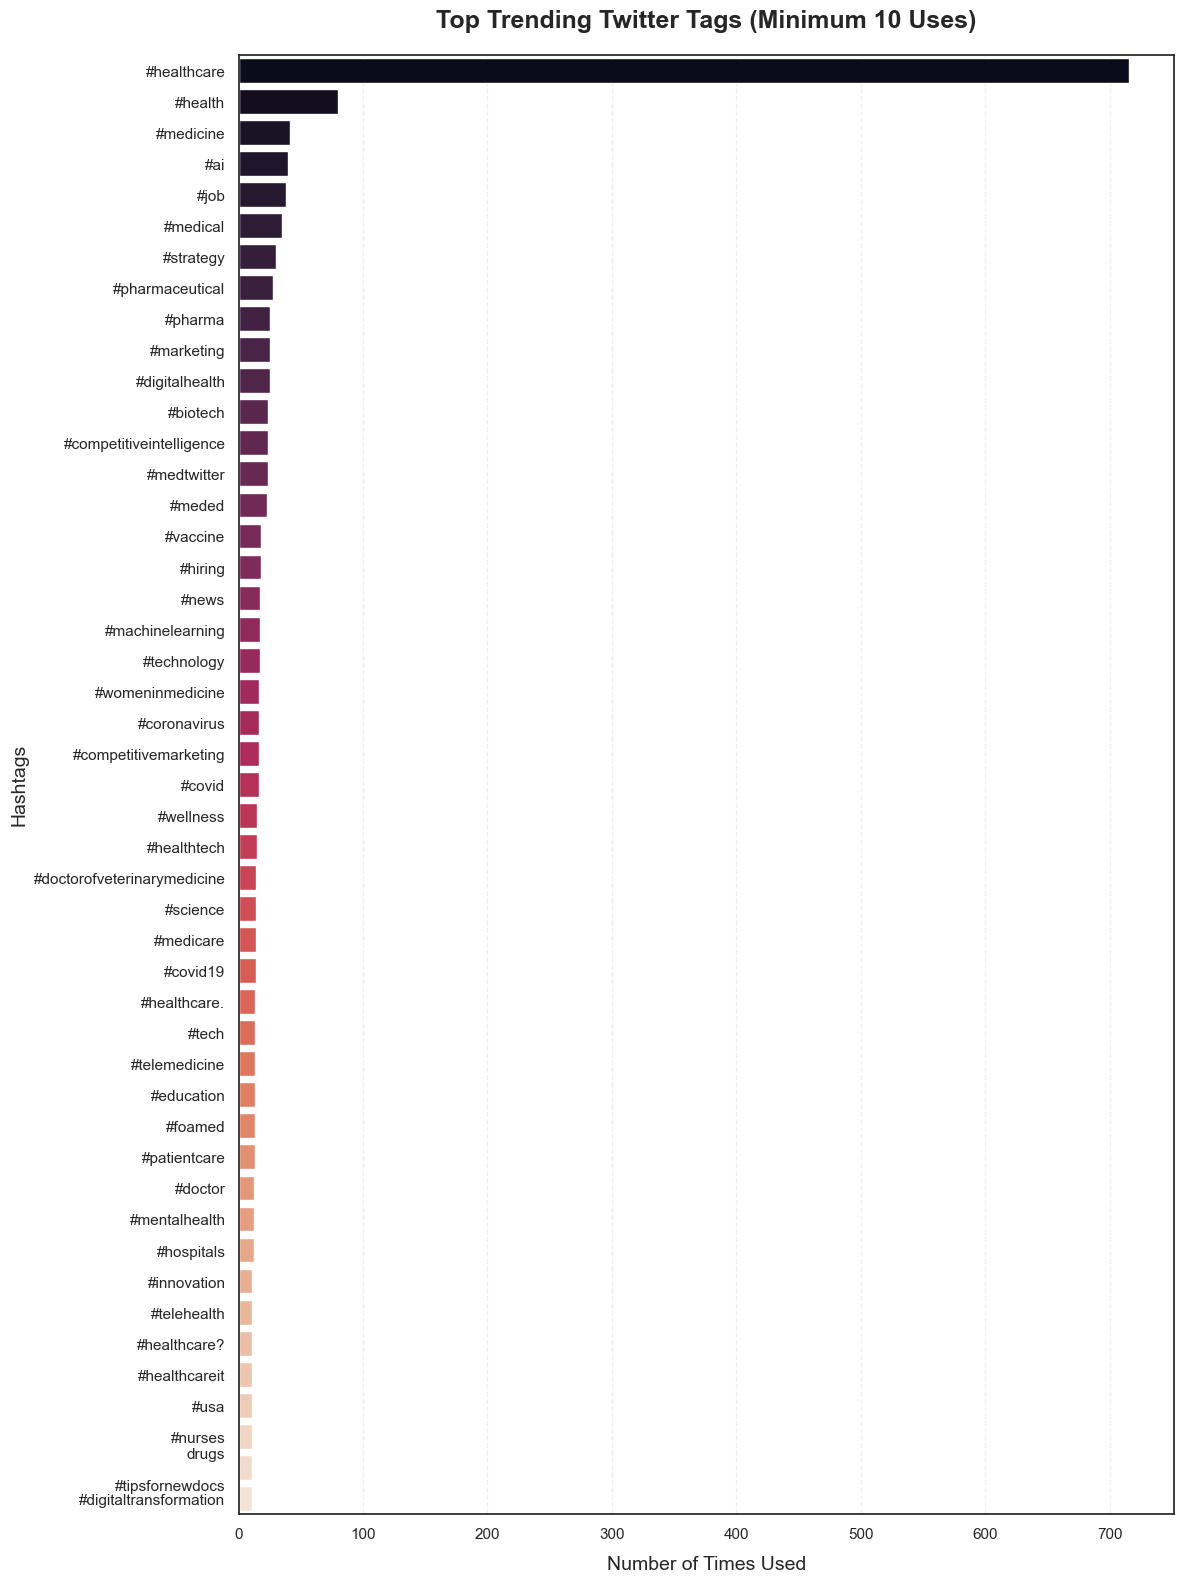

In [548]:
# Create a Seaborn barplot indicating records with a count >10 records.
tags_min_10 = tags_min_10.sort_values('Count', ascending=False)

# Create plot.
plt.figure(figsize=(12, 16))

ax = sns.barplot(
    x='Count', 
    y='Tags', 
    data=tags_min_10, 
    palette='rocket',
    hue='Tags',
    legend=False
)

# Format plot.
plt.title('Top Trending Twitter Tags (Minimum 10 Uses)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Number of Times Used', fontsize=14, labelpad=10)
plt.ylabel('Hashtags', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.3, axis='x') 
plt.tight_layout()
plt.savefig('top_twitter_tags.png', dpi=300, bbox_inches='tight')
plt.show()

'Healthcare' is by far the most used hashtag in the data set provided - difficult to draw any useful conclusions from this, other than people are talking about healthcare.

# Assignment activity 6

### Make recommendations to the NHS. 

In [82]:
# View the DataFrame.
ar

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
0,E54000034,2020-01,Attended,GP,Face-to-Face,1 Day,8107,2020-01-01
1,E54000034,2020-01,Attended,GP,Face-to-Face,15 to 21 Days,6791,2020-01-01
2,E54000034,2020-01,Attended,GP,Face-to-Face,2 to 7 Days,20686,2020-01-01
3,E54000034,2020-01,Attended,GP,Face-to-Face,22 to 28 Days,4268,2020-01-01
4,E54000034,2020-01,Attended,GP,Face-to-Face,8 to 14 Days,11971,2020-01-01
...,...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21,2022-06-01
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8,2022-06-01
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28,2022-06-01
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17,2022-06-01


In [83]:
# Print the min and max dates.
print(f"The minimum appointment date is: {ar_min_max['min'].strftime('%-d-%B-%Y')}")
print(f"The maximum appointment date is: {ar_min_max['max'].strftime('%-d-%B-%Y')}")

The minimum appointment date is: 1-January-2020
The maximum appointment date is: 1-June-2022


In [84]:
# Filter the data set to only look at data from 2021-08 onwards.
ar_filter = ar[ar['appointment_date'] >= '2021-08-01']
ar_filter

,icb_ons_code,appointment_month,appointment_status,hcp_type,appointment_mode,time_between_book_and_appointment,count_of_appointments,appointment_date
3652,E54000034,2021-08,Attended,GP,Face-to-Face,1 Day,6553,2021-08-01
3653,E54000034,2021-08,Attended,GP,Face-to-Face,15 to 21 Days,2390,2021-08-01
3654,E54000034,2021-08,Attended,GP,Face-to-Face,2 to 7 Days,10547,2021-08-01
3655,E54000034,2021-08,Attended,GP,Face-to-Face,22 to 28 Days,937,2021-08-01
3656,E54000034,2021-08,Attended,GP,Face-to-Face,8 to 14 Days,4961,2021-08-01
...,...,...,...,...,...,...,...,...
596816,E54000050,2022-06,Unknown,Unknown,Unknown,2 to 7 Days,21,2022-06-01
596817,E54000050,2022-06,Unknown,Unknown,Unknown,22 to 28 Days,8,2022-06-01
596818,E54000050,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,28,2022-06-01
596819,E54000050,2022-06,Unknown,Unknown,Unknown,More than 28 Days,17,2022-06-01


**Question 1:** Should the NHS start looking at increasing staff levels? 

In [254]:
# Create an aggregated data set to review the different features.
ar_agg = ar_filter.groupby(['appointment_month', 'hcp_type', 'appointment_status', 
                            'appointment_mode', 'time_between_book_and_appointment',
                           'appointment_date'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
ar_agg

,appointment_month,hcp_type,appointment_status,appointment_mode,time_between_book_and_appointment,appointment_date,count_of_appointments
0,2021-08,GP,Attended,Face-to-Face,1 Day,2021-08-01,507835
1,2021-08,GP,Attended,Face-to-Face,15 to 21 Days,2021-08-01,194726
2,2021-08,GP,Attended,Face-to-Face,2 to 7 Days,2021-08-01,959486
3,2021-08,GP,Attended,Face-to-Face,22 to 28 Days,2021-08-01,102111
4,2021-08,GP,Attended,Face-to-Face,8 to 14 Days,2021-08-01,398772
...,...,...,...,...,...,...,...
3749,2022-06,Unknown,Unknown,Unknown,8 to 14 Days,2022-06-01,5494
3750,2022-06,Unknown,Unknown,Unknown,More than 28 Days,2022-06-01,5115
3751,2022-06,Unknown,Unknown,Unknown,Same Day,2022-06-01,1914
3752,2022-06,Unknown,Unknown,Unknown,Unknown / Data Quality,2022-06-01,53


In [265]:
# Determine the total number of appointments per month.
ar_monthly = ar_agg.groupby('appointment_month')['count_of_appointments'].sum().reset_index()

# Add a new column to indicate the average utilisation of services.
# Monthly aggregate / 30 to get to a daily value.
ar_monthly['utilisation'] = (ar_monthly['count_of_appointments'] / 30).round(0).astype(int)
ar_monthly['utilisation_rate'] = (ar_monthly['count_of_appointments'] / 1200000).round(0).astype(int)

# Calculate the percentage of the 1.2m capacity being used.
ar_monthly['utilisation_pct'] = ((ar_monthly['utilisation'] / 1_200_000) * 100).round(2)

# View the DataFrame.
ar_monthly

,appointment_month,count_of_appointments,utilisation,utilisation_rate,utilisation_pct
0,2021-08,23852171,795072,20,66.26
1,2021-09,28522501,950750,24,79.23
2,2021-10,30303834,1010128,25,84.18
3,2021-11,30405070,1013502,25,84.46
4,2021-12,25140776,838026,21,69.84
5,2022-01,25635474,854516,21,71.21
6,2022-02,25355260,845175,21,70.43
7,2022-03,29595038,986501,25,82.21
8,2022-04,23913060,797102,20,66.43
9,2022-05,27495508,916517,23,76.38


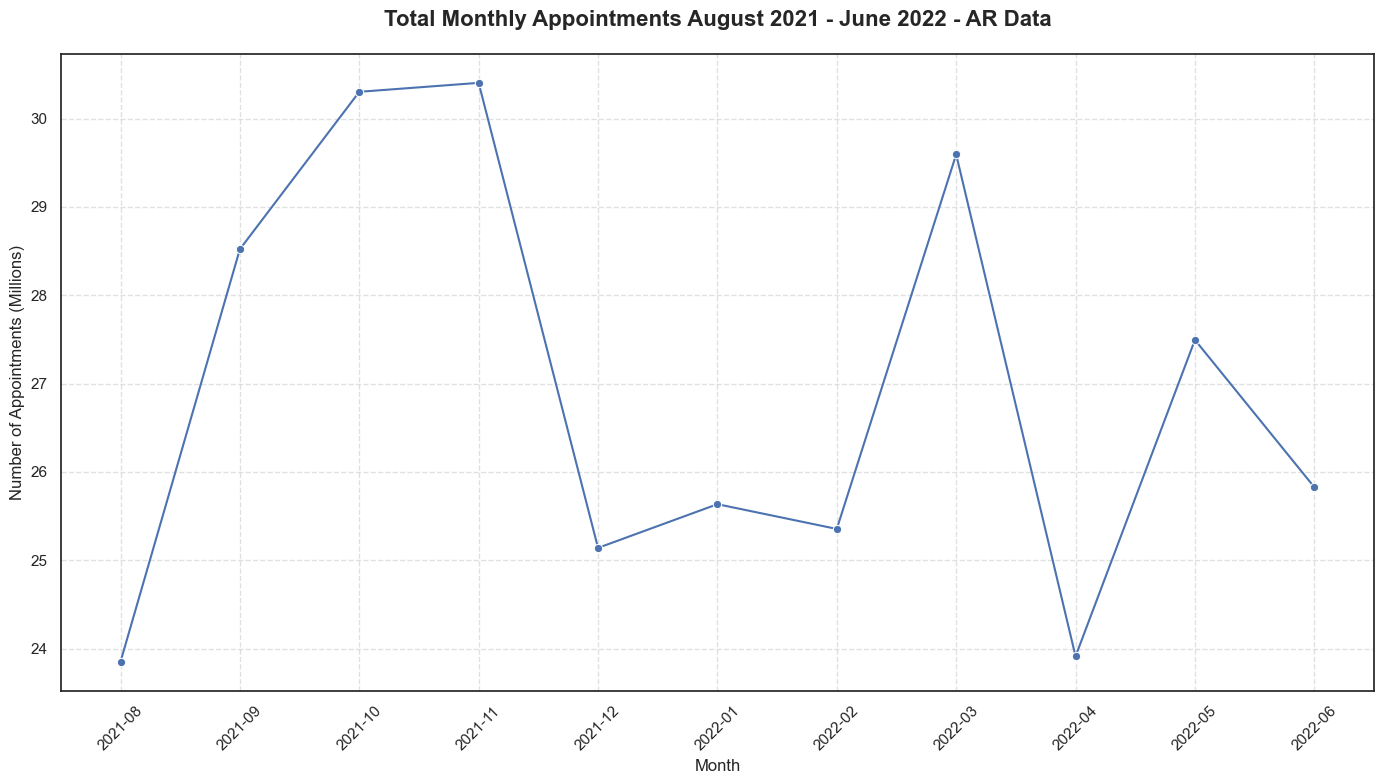

In [592]:
# Plot sum of count of monthly visits.
# Convert the appointment_month to string data type for ease of visualisation.
ar_monthly['appointment_month'].astype(str)
ar_monthly.dtypes

plt.figure(figsize=(14, 8))
# Create lineplot.
ax = sns.lineplot(x='appointment_month', 
                  y=ar_monthly['count_of_appointments'] / 1_000_000, 
                  data=ar_monthly,
                  marker='o',
                  errorbar=None
                 )

# Format plot title and labels.
plt.grid(True, linestyle='--', alpha=0.6, axis='both')
plt.title('Total Monthly Appointments August 2021 - June 2022 - AR Data', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Appointments (Millions)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('total_monthly_appointments_august_2021_june_2022_ar_data', dpi=300, bbox_inches='tight')
plt.show()

All appointment peak around Autumn 2021 and Spring 2022.\
Amount of appointments sharply decreases in winter of 2021 - possibly due to announcement of 'Plan B' measures following spread of Omicron.\
General trend is consistent with previous results.

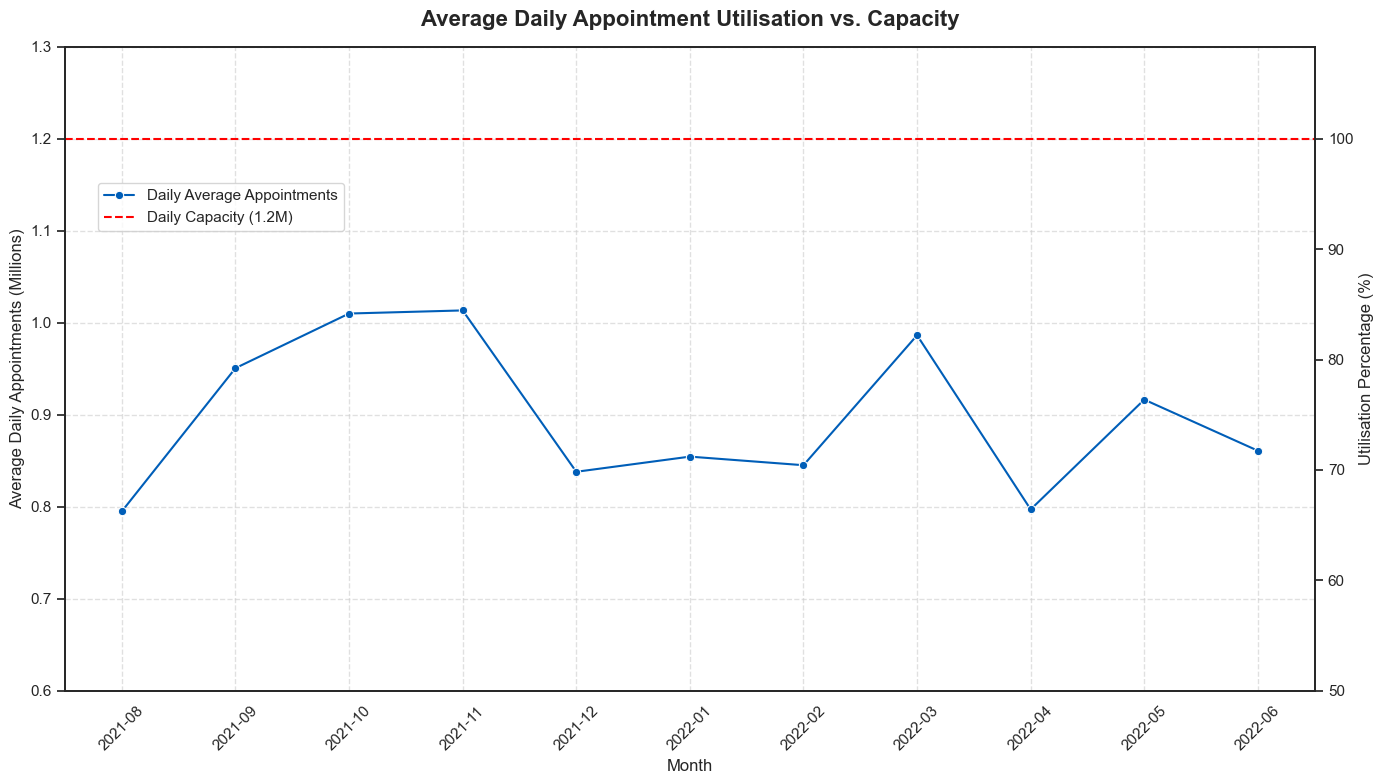

In [564]:
# Create plot showing monthly utilisation, utilisation percentage and capacity.
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.lineplot(x='appointment_month', 
             y=ar_monthly['utilisation'] / 1_000_000, 
             data=ar_monthly, 
             marker='o', 
             ax=ax1, 
             color='#005EB8', 
             label='Daily Average Appointments'
            )

# Create secondary axis to show percentage.
ax2 = ax1.twinx()

# Set left axis limit and synchronise with right axis (so 1.2M = 100%).
upper_limit = 1.3 
ax1.set_ylim(0.6, upper_limit)
ax2.set_ylim(50, (upper_limit / 1.2) * 100)

# Add capacity line.
ax1.axhline(1.2, color='red', linestyle='--', linewidth=1.5, label='Daily Capacity (1.2M)')

# Format plot.
ax1.grid(True, linestyle='--', alpha=0.6, axis='both')
plt.title('Average Daily Appointment Utilisation vs. Capacity', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Average Daily Appointments (Millions)', fontsize=12)
ax2.set_ylabel('Utilisation Percentage (%)', fontsize=12)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, bbox_to_anchor=(0.02, 0.8), loc='upper left')

ax1.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('average_daily_utilisation_vs_capacity.png', dpi=300, bbox_inches='tight')
plt.show()

In [605]:
# Determine the total number of appointments per day.
nc_daily = nc.groupby('appointment_date')['count_of_appointments'].sum().reset_index()

# View the DataFrame.
nc_daily

,appointment_date,count_of_appointments
0,2021-08-01,5627
1,2021-08-02,1222768
2,2021-08-03,1169920
3,2021-08-04,1093532
4,2021-08-05,1074043
...,...,...
329,2022-06-26,6574
330,2022-06-27,1410883
331,2022-06-28,1335598
332,2022-06-29,1237258


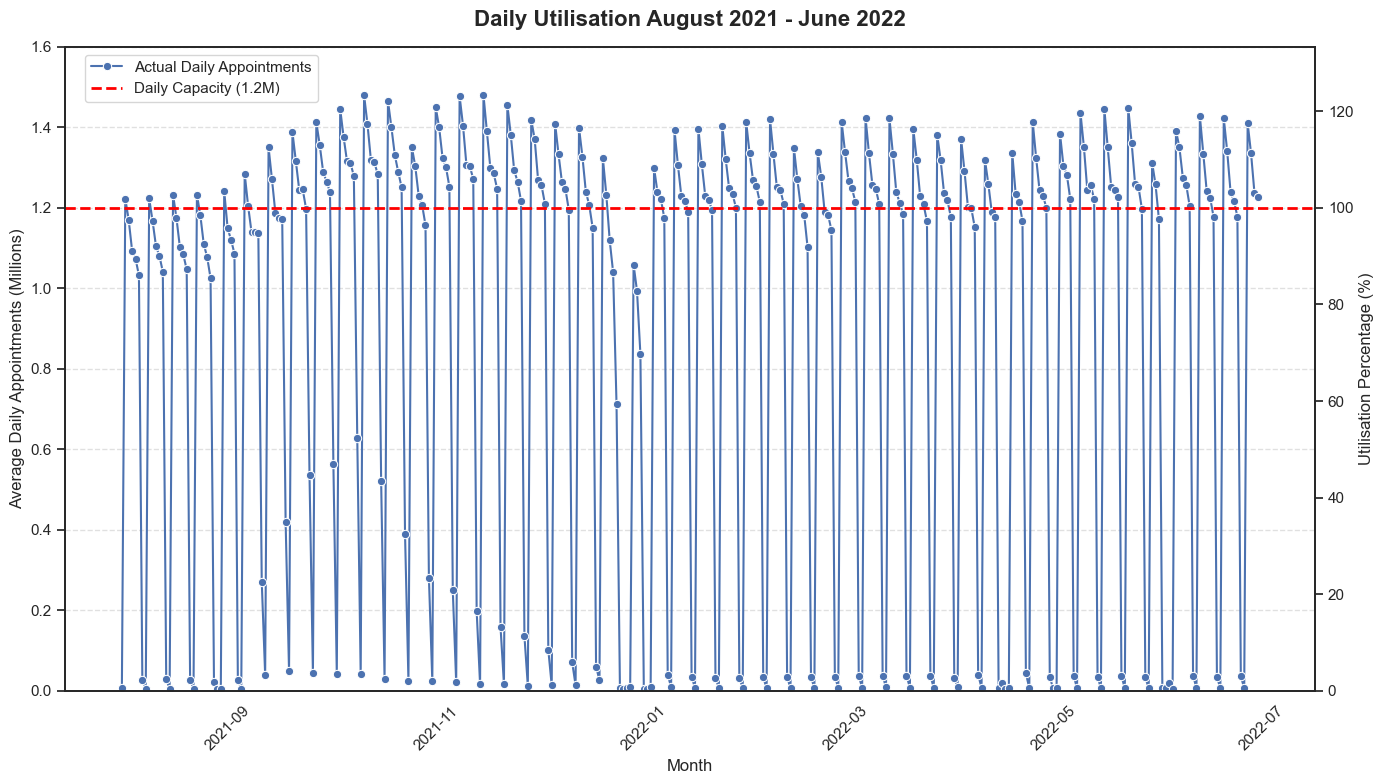

In [614]:
# Plot results.
fig, ax1 = plt.subplots(figsize=(14, 8))
sns.lineplot(x='appointment_date', 
             y=nc_daily['count_of_appointments'] / 1_000_000, 
             data=nc_daily, 
             label='Actual Daily Appointments',
             marker='o',
             errorbar=None,
            )

# Create secondary axis to show percentage.
ax2 = ax1.twinx()

# Set left axis limit and synchronise with right axis (so 1.2M = 100%).
upper_limit = 1.6
ax1.set_ylim(0, upper_limit)
ax2.set_ylim(0, (upper_limit / 1.2) * 100)
ax1.axhline(y=1.2, color='red', linestyle='--', linewidth=2, label='Daily Capacity (1.2M)')

# Format plot title and labels.
ax1.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.title('Daily Utilisation August 2021 - June 2022', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Average Daily Appointments (Millions)', fontsize=12)
ax2.set_ylabel('Utilisation Percentage (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
ax1.legend(lines, labels, bbox_to_anchor=(0.01, 1), loc='upper left')

plt.tight_layout()
plt.savefig('daily_utilisation_august_2021_june_2022')
plt.show()

Although average daily utilisation never exceeds 85% capacity, it is clear that total daily appointments consistently exceed the 1.2m benchmark - also seen earlier with the daily trends between seasons. Average is calculated over 30 days which includes weekends; numbers are drastically decreased, giving false impression that capacity is never reached, or exceeded.\
In reality there are negligible amounts of weekend appointments.\
NHS should increase staff numbers to deal with the pressure, perhaps hiring weekend staff would allow a more even spread of appointments over the week. 

**Question 2:** How do the healthcare professional types differ over time?

In [431]:
# Create new df excluding unknown HCPs.
hcp_trends = ar_agg.groupby(['appointment_month', 
                             'hcp_type'])['count_of_appointments'].sum().reset_index()

# Add filter.
hcp_trends = hcp_trends[hcp_trends['hcp_type'] != 'Unknown']
hcp_trends

,appointment_month,hcp_type,count_of_appointments
0,2021-08,GP,12299022
1,2021-08,Other Practice staff,10797821
3,2021-09,GP,14487785
4,2021-09,Other Practice staff,13126731
6,2021-10,GP,14300751
7,2021-10,Other Practice staff,14942504
9,2021-11,GP,14897749
10,2021-11,Other Practice staff,14432800
12,2021-12,GP,12654767
13,2021-12,Other Practice staff,11614470


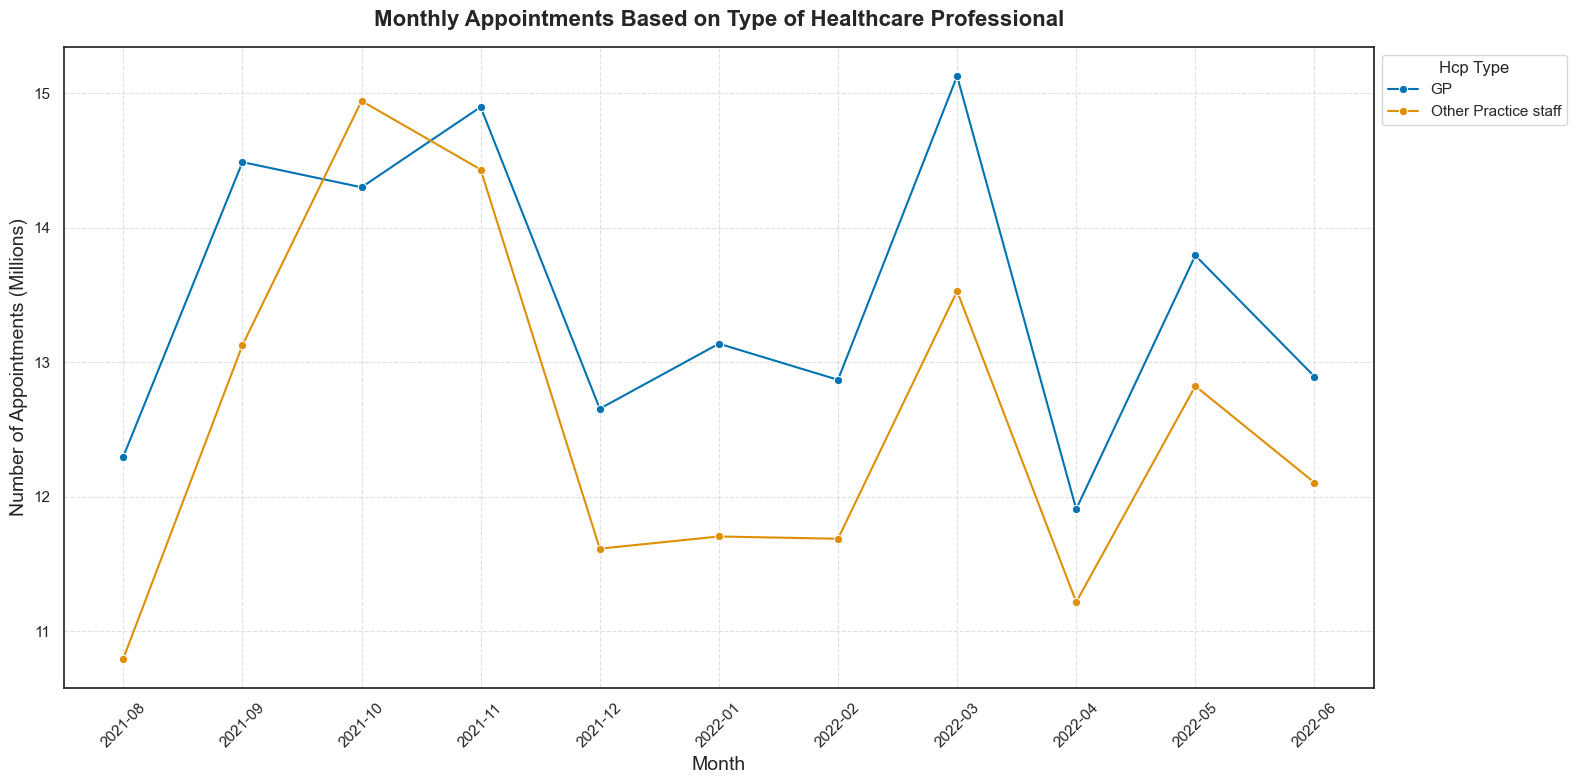

In [565]:
# Use monthly trends function to answer question.
monthly_trends(hcp_trends, 
               'hcp_type', 
               'Monthly Appointments Based on Type of Healthcare Professional')

GP and Other Practice staff provide most of the appointments - unknown staff were excluded from analysis. \
More granularity is needed for Other Practice staff category - knowing which type of staff are providing care would be helpful for analysis.\
GPs consistently provide more appointments than other practice staff, with the exception of October 2021 when the number of appointments was highest - suggesting GPs were working at over capacity and reliance on other staff increased to deal with pressure.

**Question 3:** Are there significant changes in whether or not visits are attended?

In [429]:
dna_trends = ar_agg.groupby(['appointment_month', 
                             'appointment_status'])['count_of_appointments'].sum().reset_index()
dna_trends

,appointment_month,appointment_status,count_of_appointments
0,2021-08,Attended,22081765
1,2021-08,DNA,949137
2,2021-08,Unknown,821269
3,2021-09,Attended,25757066
4,2021-09,DNA,1321348
5,2021-09,Unknown,1444087
6,2021-10,Attended,27170506
7,2021-10,DNA,1565624
8,2021-10,Unknown,1567704
9,2021-11,Attended,27667665


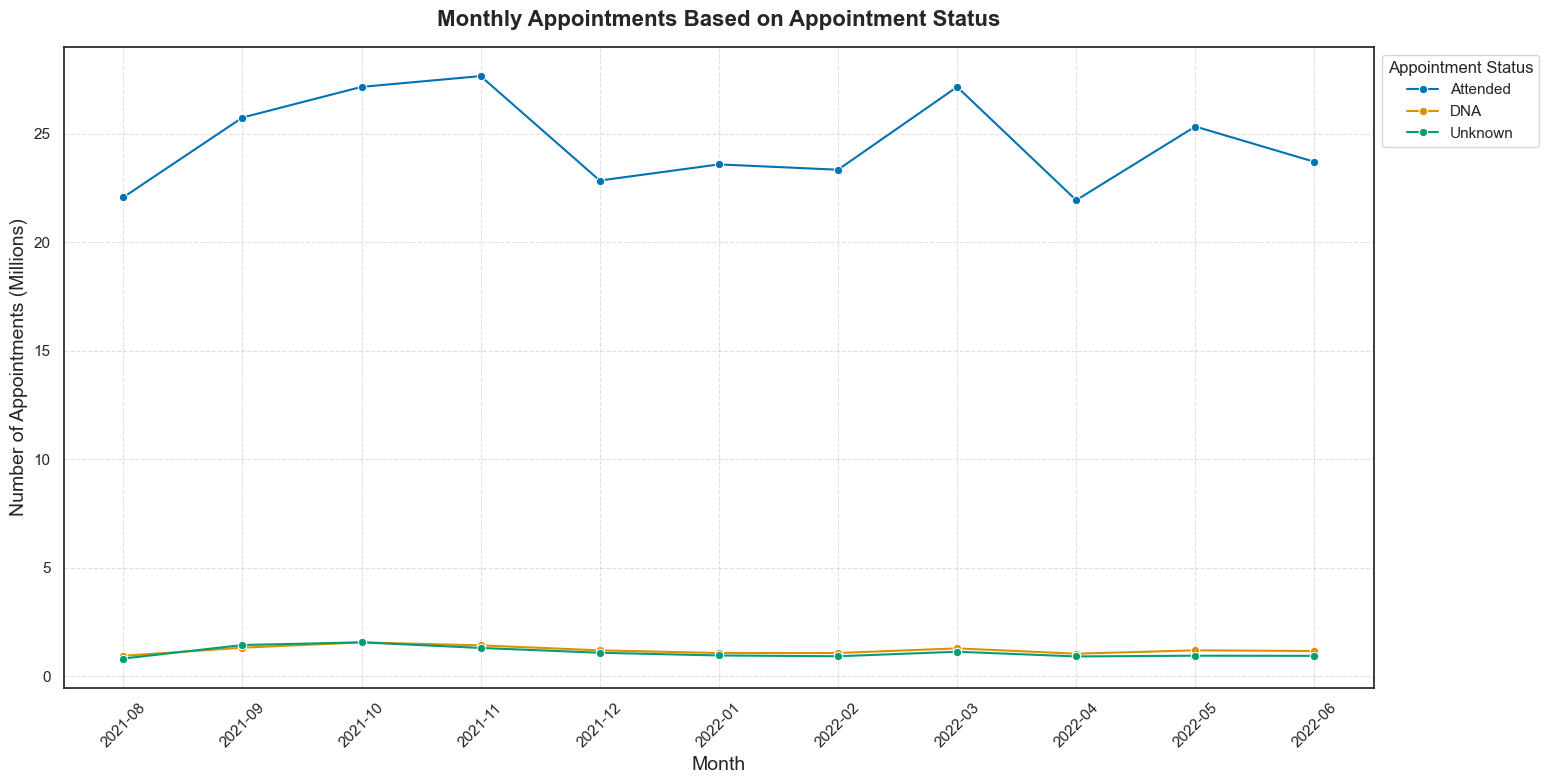

In [566]:
# Create a line plot to answer the question using monthly trends function.
monthly_trends(dna_trends, 
               'appointment_status', 
               'Monthly Appointments Based on Appointment Status')

In [340]:
# Filter out attended appointments to visulaise DNA and unknown more clearly.
dna_filter = dna_trends[dna_trends['appointment_status'] != 'Attended']
dna_filter

,appointment_month,appointment_status,count_of_appointments
1,2021-08,DNA,949137
2,2021-08,Unknown,821269
4,2021-09,DNA,1321348
5,2021-09,Unknown,1444087
7,2021-10,DNA,1565624
8,2021-10,Unknown,1567704
10,2021-11,DNA,1428087
11,2021-11,Unknown,1309318
13,2021-12,DNA,1198866
14,2021-12,Unknown,1088427


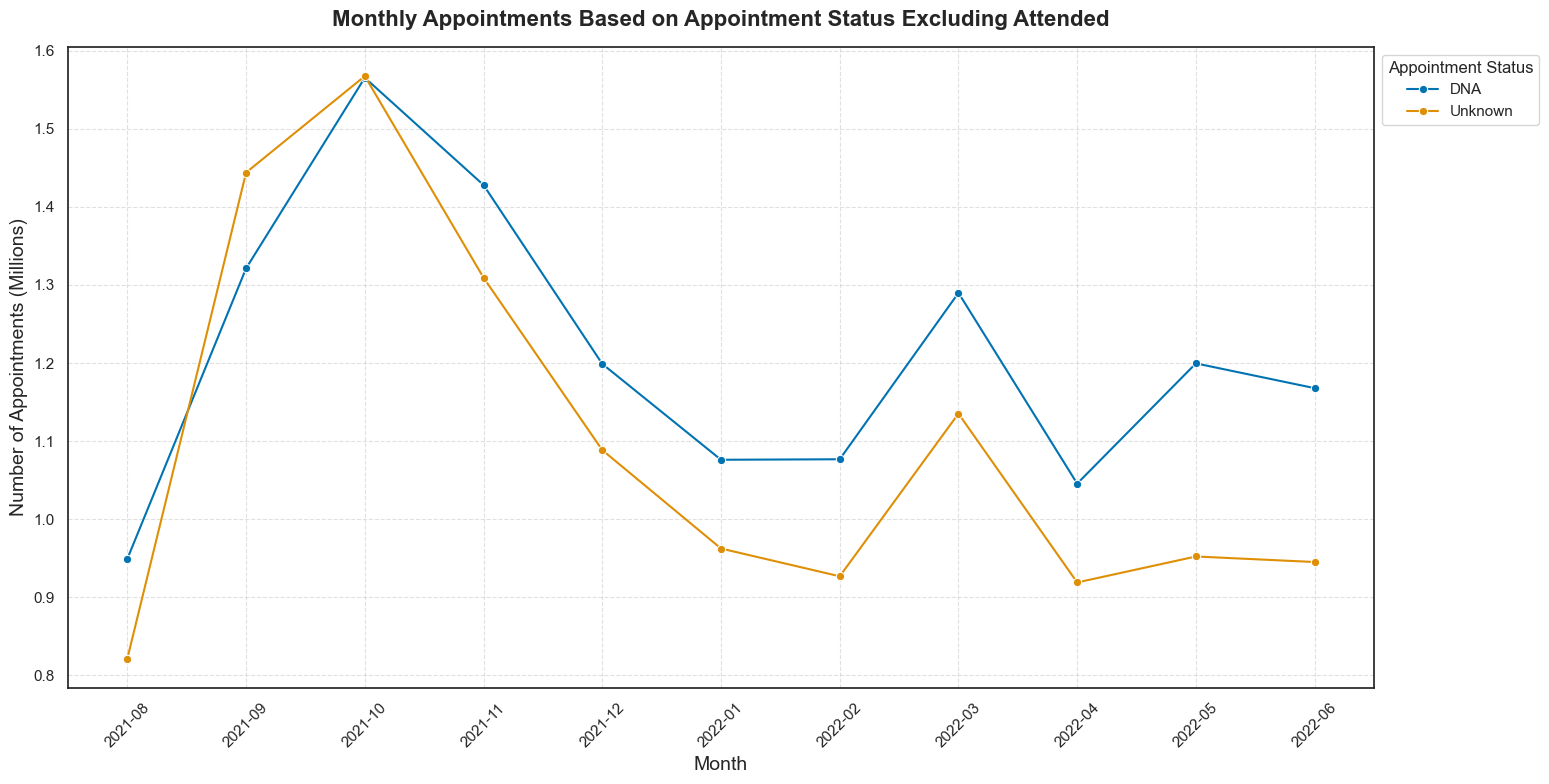

In [602]:
# Create a line plot using monthly trends function.
monthly_trends(dna_filter, 
               'appointment_status', 
               'Monthly Appointments Based on Appointment Status Excluding Attended')

Number of not attended appointments follows trend of total appointments; the more appointments there are, the more appointments are missed.\
Most missed appointments in October 2021.

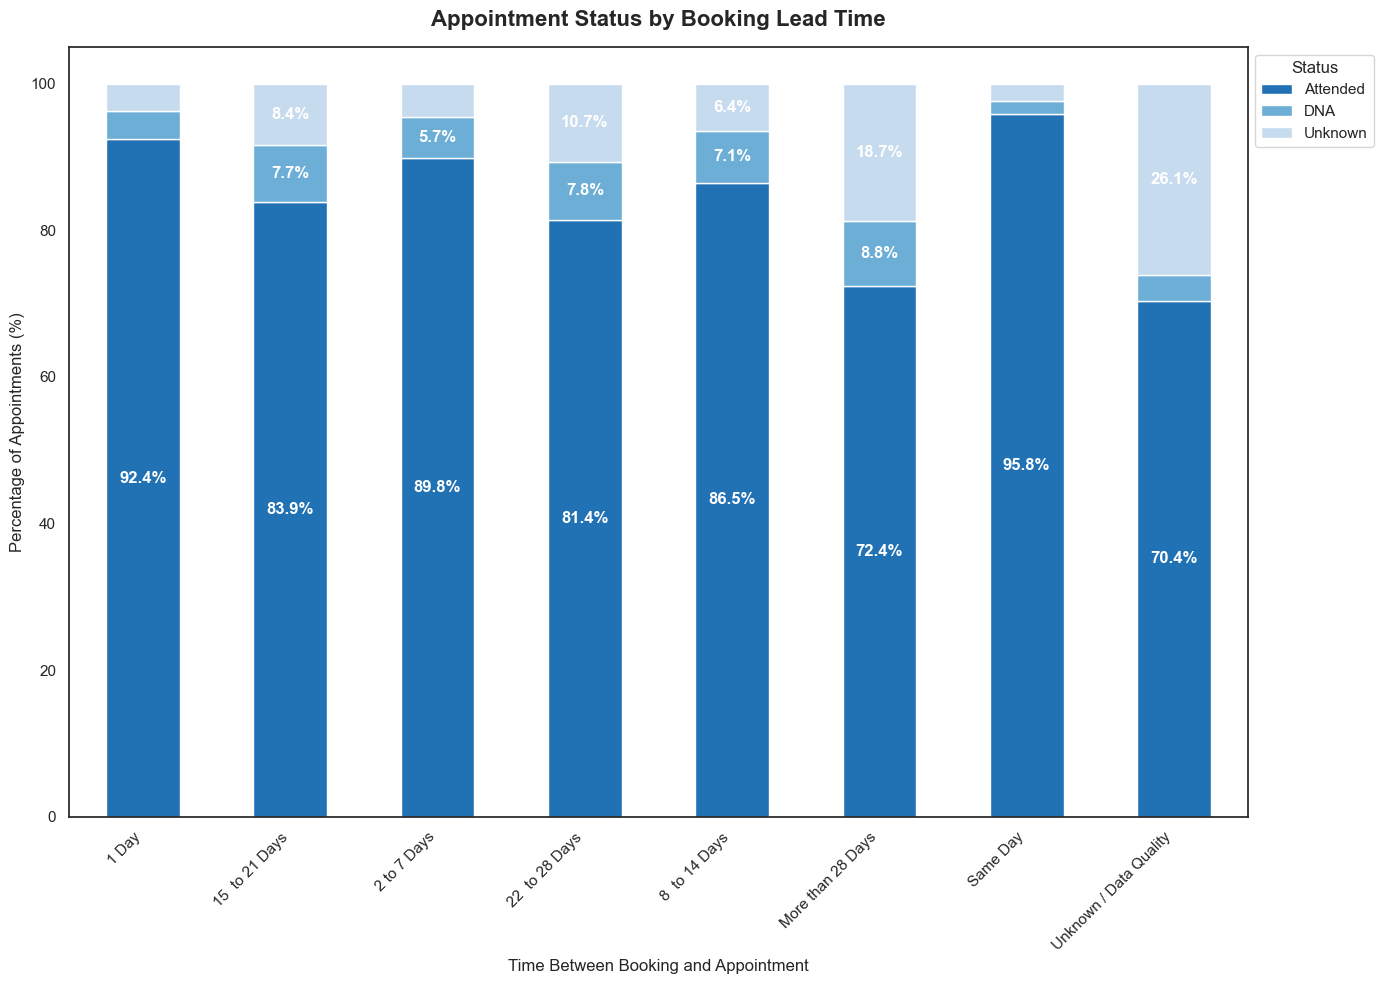

In [596]:
# Analyse relationship between appointment status and booking lead time.
lead_time = ar.groupby(['time_between_book_and_appointment', 
                             'appointment_status'])['count_of_appointments'].sum().unstack()

# Convert to percentages to display on chart.
status_perc = lead_time.divide(lead_time.sum(axis=1), axis=0) * 100

# Plot results.
palette = sns.color_palette("Blues_r", 3)
ax = status_perc.plot(kind='bar', stacked=True, figsize=(14, 10), color=palette)

# Format plot title and labels.
plt.title('Appointment Status by Booking Lead Time', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Percentage of Appointments (%)', fontsize=12)
plt.xlabel('Time Between Booking and Appointment', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Status', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

# Add percentage labels inside bars.
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Only show label if the segment is large enough.
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', 
                    va='center', 
                    color='white', 
                    fontweight='bold')

plt.savefig('appointment_status_by_booking_lead_time', dpi=300, bbox_inches='tight')        
plt.show()

The lowest percentage of missed appointments are same day appointments. The highest percentage of missed appointments are appointments when wait time is over 28 days, suggesting patients sought alternative care/ treatment, or no longer needed the apopintment.\
Implementing a system where practices contact patients where appointment was booked > 3 weeks in advance to confirm need for appointment would free up appointment slots for patients who neeed them. Perhaps a task for weekend administrative staff.

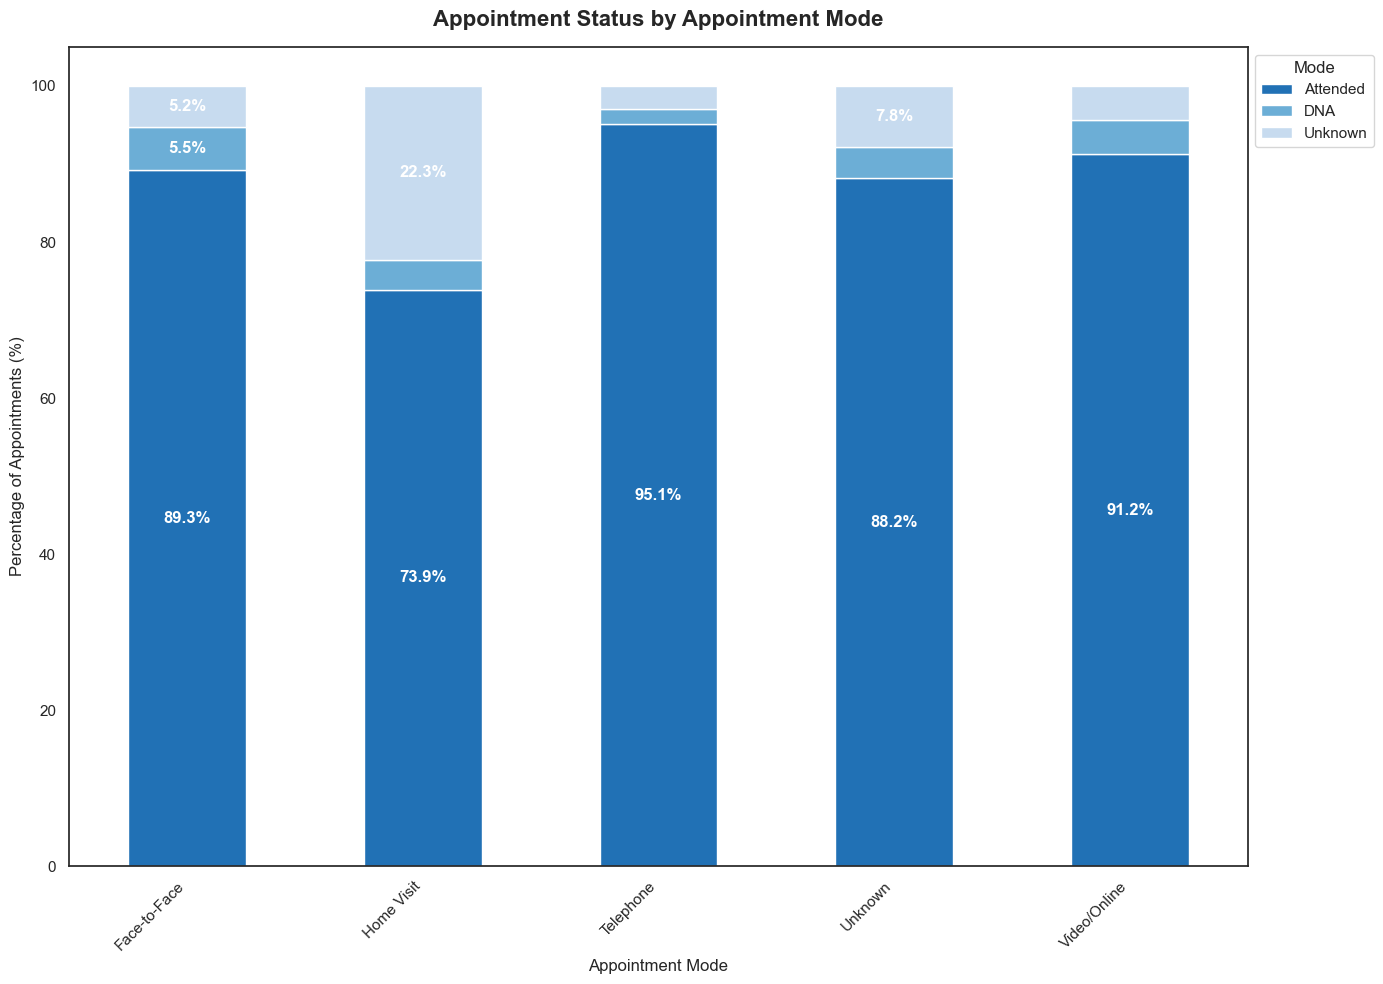

In [595]:
# Analyse relationship between appointment status and appointment mode.
wait_time = ar.groupby(['appointment_mode', 
                             'appointment_status'])['count_of_appointments'].sum().unstack()

# Convert to percentages to display on chart.
status_perc = wait_time.divide(wait_time.sum(axis=1), axis=0) * 100

# Plot results.
palette = sns.color_palette("Blues_r", 3)
ax = status_perc.plot(kind='bar', stacked=True, figsize=(14, 10), color=palette)

# Format plot title and labels.
plt.title('Appointment Status by Appointment Mode', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Percentage of Appointments (%)', fontsize=12)
plt.xlabel('Appointment Mode', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mode', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()

# Add percentage labels inside bars.
for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: 
        ax.annotate(f'{height:.1f}%', 
                    (x + width/2, y + height/2), 
                    ha='center', 
                    va='center', 
                    color='white', 
                    fontweight='bold')
        
plt.savefig('appointment_status_by_appointment_mode.png', dpi=300, bbox_inches='tight')   
plt.show()

Highest percentage of missed appointments are face-to-face appointments, the lowest percentage of missed appointments are telephone appointments. Increasing amount of telephone appointments for non-urgent care would free up face-to-face appointment slots by creating more availability but also by decreasing missed appointment numbers. 

**Question 4:** Are there changes in terms of appointment type and the busiest months?

In [426]:
mode_trends = ar_agg.groupby(['appointment_month', 
                              'appointment_mode'])['count_of_appointments'].sum().reset_index()
mode_trends

,appointment_month,appointment_mode,count_of_appointments
0,2021-08,Face-to-Face,13717325
1,2021-08,Home Visit,151619
2,2021-08,Telephone,9149072
3,2021-08,Unknown,724126
4,2021-08,Video/Online,110029
5,2021-09,Face-to-Face,17266602
6,2021-09,Home Visit,171829
7,2021-09,Telephone,10068770
8,2021-09,Unknown,859946
9,2021-09,Video/Online,155354


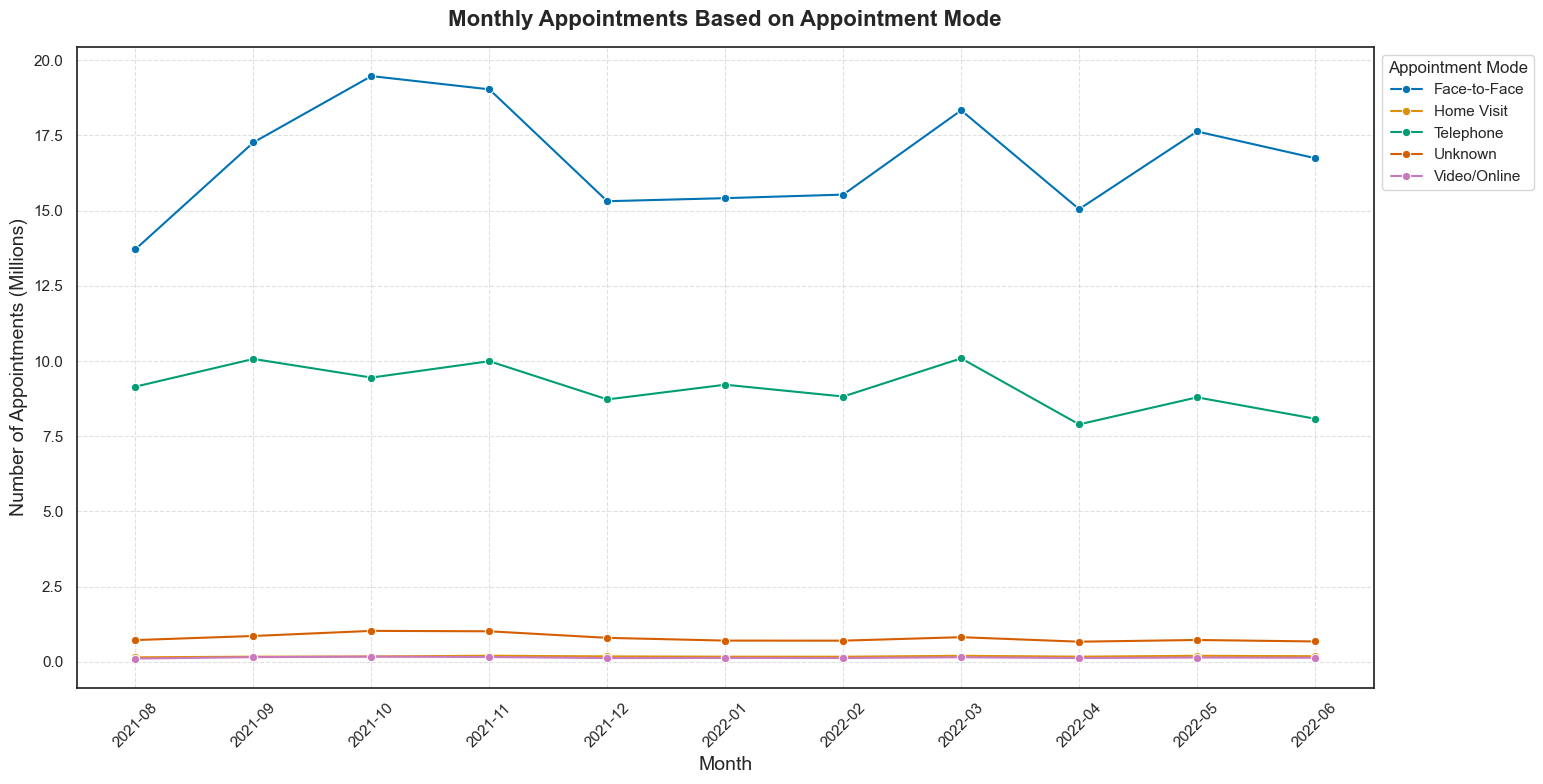

In [571]:
# Create a line plot to answer the question using the monthly trends function.
monthly_trends(mode_trends, 
               'appointment_mode', 
               'Monthly Appointments Based on Appointment Mode')

Telephone appointments decrease in October 2021 when there is a sharp rise in face-to-face appointments.
There is a slight increase in telephone appointments in January 2022, again, likely due to introduction of Plan B measures (face masks, work from home etc.)

**Question 5:** Are there any trends in time between booking and appointment?

In [423]:
lead_trends = ar_agg.groupby(['appointment_month', 
                              'time_between_book_and_appointment'])['count_of_appointments'].sum().reset_index()
lead_trends

,appointment_month,time_between_book_and_appointment,count_of_appointments
0,2021-08,1 Day,2018319
1,2021-08,15 to 21 Days,1453209
2,2021-08,2 to 7 Days,4924960
3,2021-08,22 to 28 Days,828866
4,2021-08,8 to 14 Days,2889150
...,...,...,...
83,2022-06,22 to 28 Days,1217197
84,2022-06,8 to 14 Days,3250347
85,2022-06,More than 28 Days,1067420
86,2022-06,Same Day,11461923


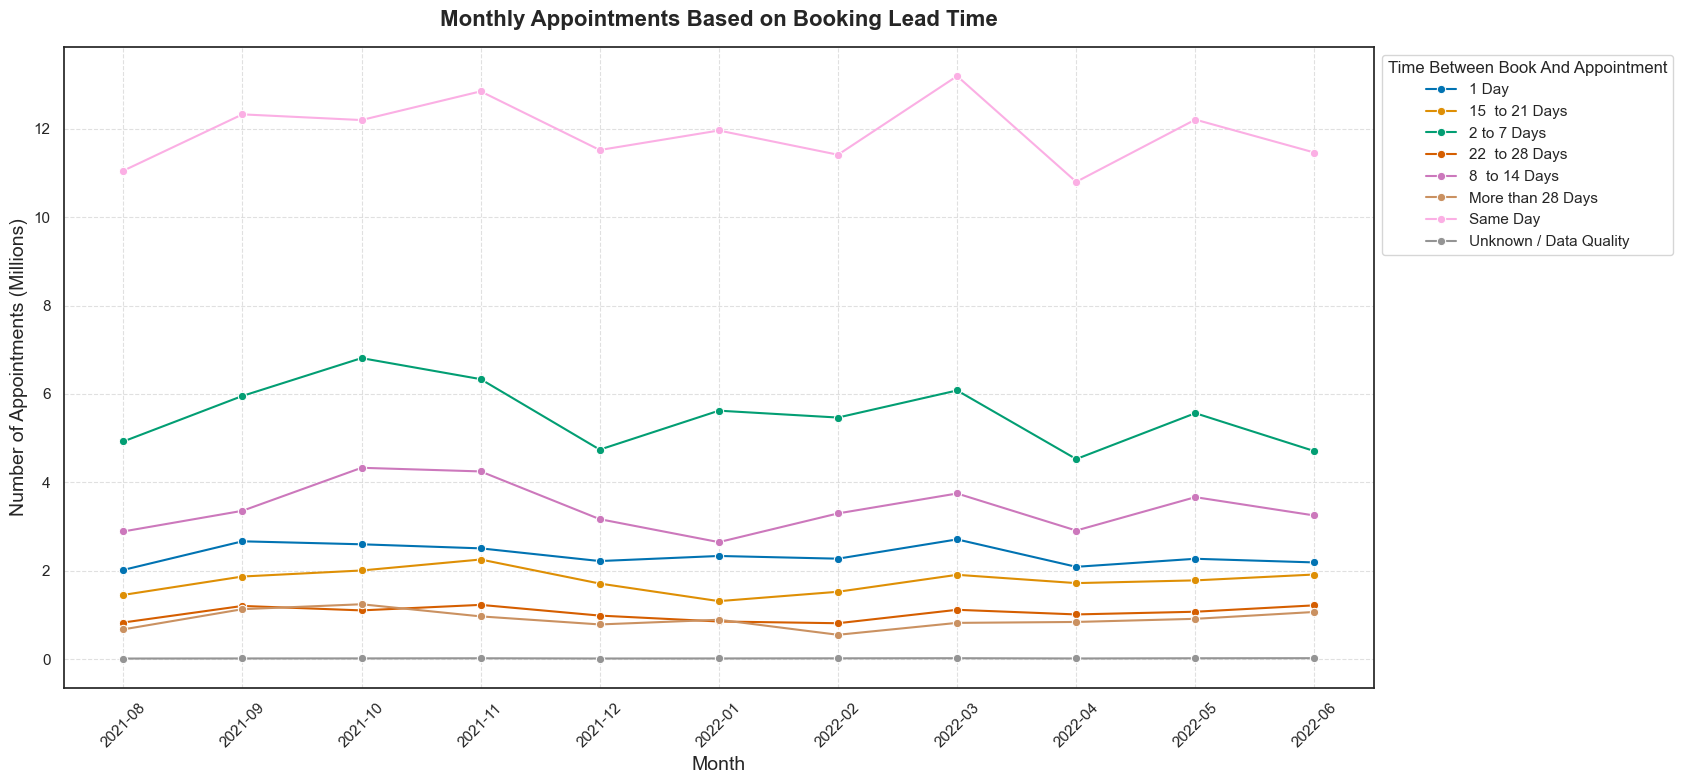

In [616]:
# Create a line plot to answer the question using monthly trends function.
monthly_trends(lead_trends, 
               'time_between_book_and_appointment', 
               'Monthly Appointments Based on Booking Lead Time')

When total number of appointments is highest (October 2021) there is a slight decrease in same day appointments and a marked increase in 2-7 day wait for appointment; confirming GPs operating over capacity as availability of same day slots is decreased. 

In [599]:
# Filter to only view appointments with > 28 day lead time.
lead_filter = lead_trends[lead_trends['time_between_book_and_appointment'] == 'More than 28 Days']
lead_filter

,appointment_month,time_between_book_and_appointment,count_of_appointments
5,2021-08,More than 28 Days,673225
13,2021-09,More than 28 Days,1130118
21,2021-10,More than 28 Days,1241794
29,2021-11,More than 28 Days,967303
37,2021-12,More than 28 Days,785009
45,2022-01,More than 28 Days,890975
53,2022-02,More than 28 Days,550847
61,2022-03,More than 28 Days,820399
69,2022-04,More than 28 Days,841319
77,2022-05,More than 28 Days,912129


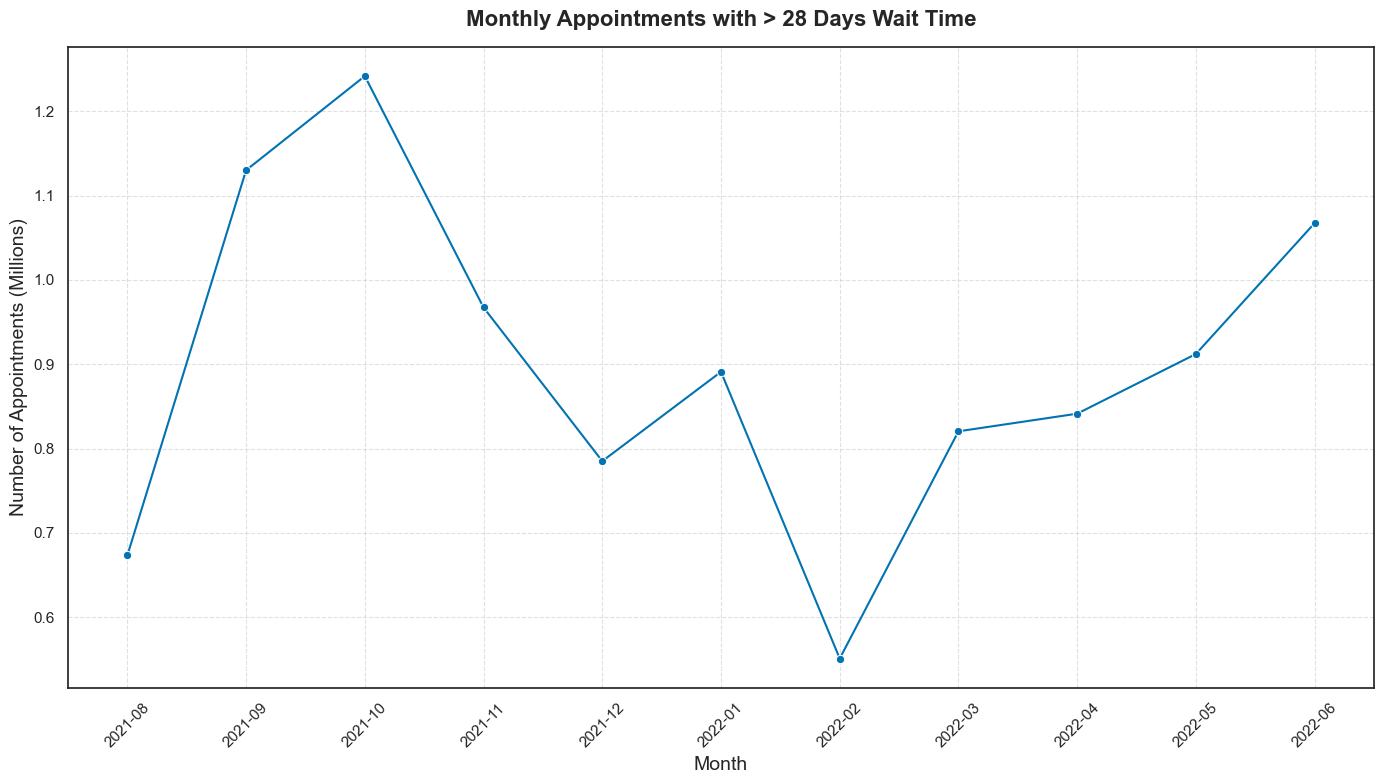

In [615]:
# Plot results using monthly trends function.
monthly_trends(lead_filter, 'time_between_book_and_appointment', 
               'Monthly Appointments with > 28 Days Wait Time',
               show_legend=False)

**Question 6:** How do the various service settings compare?

In [230]:
# Let's go back to the national category DataFrame you created in an earlier assignment activity.
nc.head()

,appointment_date,icb_ons_code,sub_icb_location_name,service_setting,context_type,national_category,count_of_appointments,appointment_month
0,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Primary Care Network,Care Related Encounter,Patient contact during Care Home Round,3,2021-08
1,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,Other,Care Related Encounter,Planned Clinics,7,2021-08
2,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Home Visit,79,2021-08
3,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,General Consultation Acute,725,2021-08
4,2021-08-02,E54000050,NHS North East and North Cumbria ICB - 00L,General Practice,Care Related Encounter,Structured Medication Review,2,2021-08


In [231]:
# Create a new DataFrame consisting of the month of appointment and the number of appointments.
nc_agg = nc.groupby(['appointment_month', 'service_setting'])['count_of_appointments'].sum().reset_index()

# View the DataFrame.
nc_agg

,appointment_month,service_setting,count_of_appointments
0,2021-08,Extended Access Provision,160927
1,2021-08,General Practice,21575852
2,2021-08,Other,449101
3,2021-08,Primary Care Network,432448
4,2021-08,Unmapped,1233843
5,2021-09,Extended Access Provision,187906
6,2021-09,General Practice,25940821
7,2021-09,Other,527174
8,2021-09,Primary Care Network,530485
9,2021-09,Unmapped,1336115


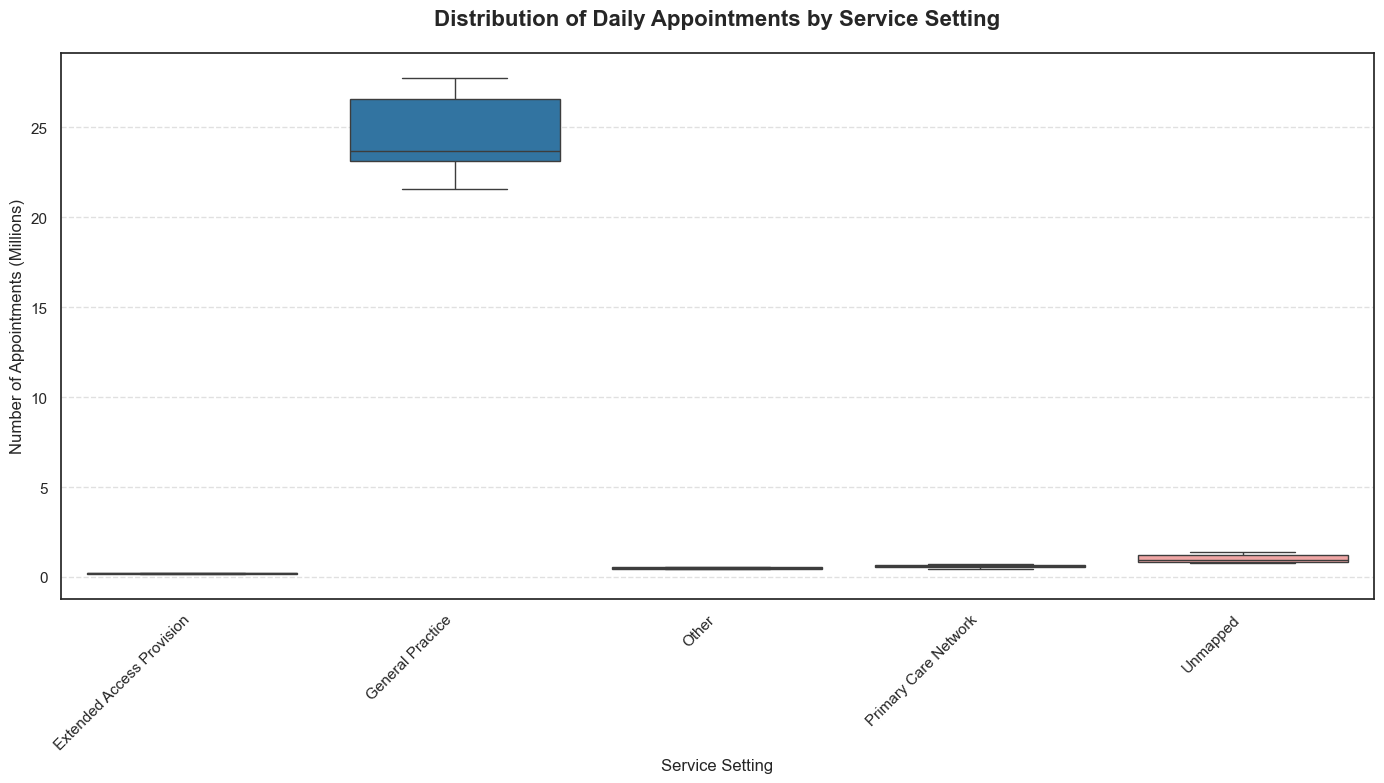

In [575]:
# Create a boxplot in Seaborn based on the new DataFrame to indicate the service settings for the number of appointments.
plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=nc_agg, 
    x='service_setting', 
    y=nc_agg['count_of_appointments'] / 1_000_000,
    palette='Paired'
)

# Format plot.
plt.title('Distribution of Daily Appointments by Service Setting', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Number of Appointments (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.savefig('distribution_of_daily_appointments_by_service_setting.png', dpi=300, bbox_inches='tight')
plt.show()

Boxplot shows no outliers for any service setting, General Practice is positively skewed, remaining categories too small to analyse.

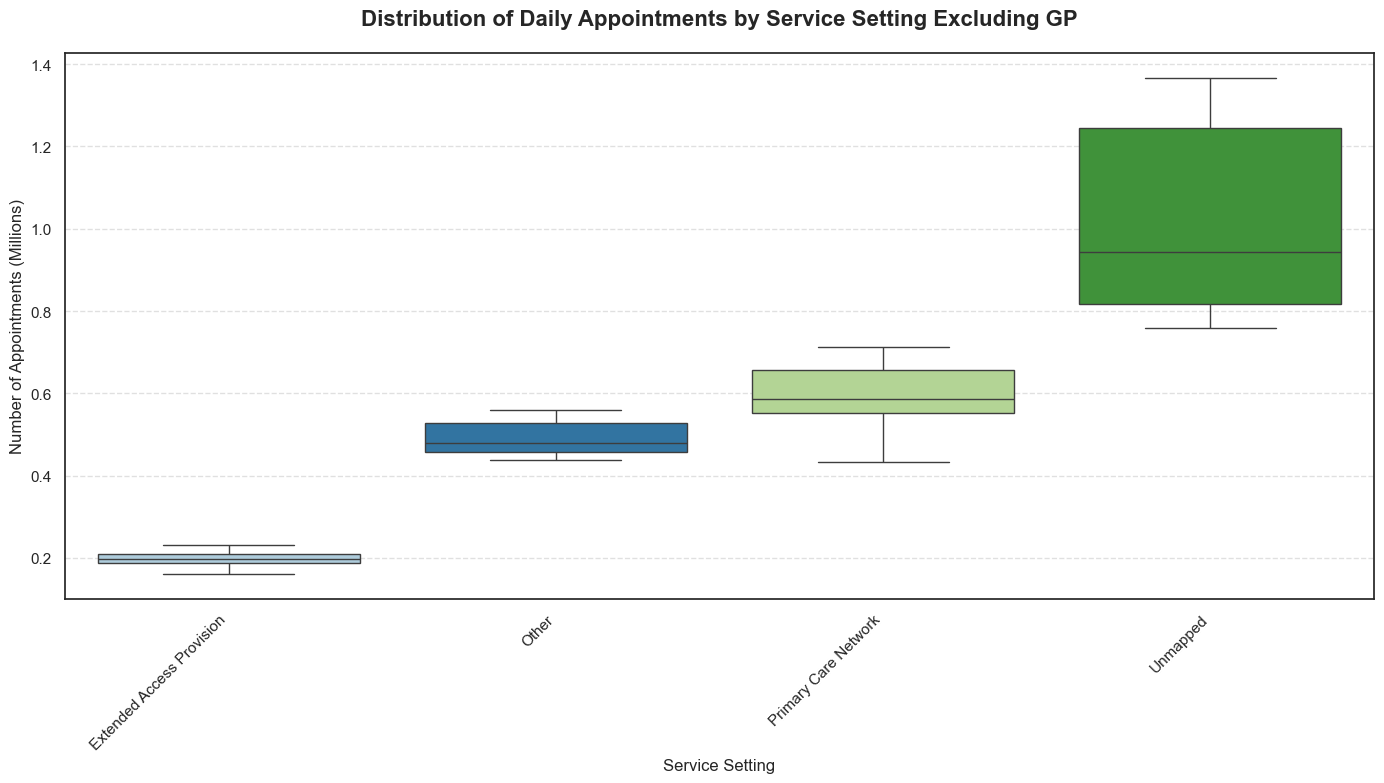

In [576]:
# Create a boxplot in Seaborn where you concentrate on all the service settings, excluding GP visits.
nc_filter = nc_agg[nc_agg['service_setting'] != 'General Practice']

plt.figure(figsize=(14, 8))

ax = sns.boxplot(
    data=nc_filter, 
    x='service_setting', 
    y=nc_agg['count_of_appointments'] / 1_000_000,
    palette='Paired'
)

# Format plot.
plt.title('Distribution of Daily Appointments by Service Setting Excluding GP', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Service Setting', fontsize=12)
plt.ylabel('Number of Appointments (Millions)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6, axis='y')
plt.tight_layout()
plt.savefig('distribution_of_daily_appointments_by_service_setting_excluding_gp.png', dpi=300, bbox_inches='tight')
plt.show()

At a closer look we can see that unmapped and other service settings are also positively skewed. \
PCN - large upper quartile suggests unpredictability during high-demand periods, elongated bottom whisker reflects intermittent drops in activity during public holidays.

# 

### Provide a summary of your findings and recommendations based on the analysis.

#### Service Setting Insights
GPs account for over 91% of appointments, while the Primary Care Network (PCN) provides only 2.2%. Increasing the number of PCN appointments could alleviate some pressure on GPs.\
There are three context types in total (NHS): Care Related Encounter, Care Related Activities, and Administration and Practice Staff Activities. Despite 13% of appointments being marked as Inconsistent Mapping and Unmapped, we can infer that this percentage likely consists of Care Related Activities and Administration tasks. Reducing this percentage could free up time for high-value activities such as patient visits.

#### National Categories and Appointment Status
65% of all appointments comprise General Consultation Routine, Planned Clinics, and Clinical Triage, while 13% are attributed to Inconsistent Mapping and Unmapped categories. \
Approximately 4.16% of appointments are marked as not attended. Investigations into whether there are common appointment types or service settings associated with these missed appointments are warranted. Additionally, 4.6% of appointments have an unknown status, which should be minimised.

#### Healthcare Professional Type
GPs account for over half of the healthcare professional types, with 45% comprised of other practice staff. Greater granularity in this data would enable more informed analysis regarding the specific roles of staff providing care.

#### Appointment Mode and Booking Lead Time
Nearly 60% of appointments are face-to-face, while telephone appointments account for 36%. Video/online appointments represent a mere 0.49%, suggesting that increasing this mode of appointment could ease reliance on face-to-face consultations. Lead time analysis revealed that 46% of appointments are same-day bookings, followed by 20% booked 2-7 days in advance. While this is beneficial for patients, it indicates a reactive approach to care, leaving little capacity for planned services.

#### Actual Duration
A significant portion (almost 25%) of appointments have an unknown duration, while over 37% last between 1-10 minutes. This data quality issue requires addressing, and a consideration of reducing the number of short appointments should be made.

#### Temporal Trends
The highest number of appointments occurred in October and November 2021, followed by a sharp decline in March 2020 due to the first UK lockdown. Appointment numbers increased again in May 2020, following the easing of restrictions.\
A pattern emerged showing that appointment numbers sharply increase every Monday, with a subsequent decline throughout the week and a significant fall over the weekend. Most weeks in Autumn 2021 exceeded capacity from Monday to Friday, barring a few exceptions due to holidays.

#### Seasonal Trends
Data for summer 2021 is limited, making it challenging to draw comprehensive conclusions about seasonal variability. However, the overall trend indicates a consistent pattern of high appointment numbers at the start of the week, with a notable decrease on weekends. Consistent exceeding of capacity during the week.

#### Twitter Data Insights
Analysis of Twitter data revealed that nearly half of the tweets are not retweeted, and most have not been favourited. The most frequently used hashtag, 'healthcare', indicates that discussions surrounding healthcare are prevalent, though extracting actionable insights from this data remains challenging.